# Proyecto Final de Machine Learning - Dataset SUPPORT2

## Nuria Rapún Gimeno, Irene Gil Biurrun, Carla Lombardero Haya y Fernando Flecha Bayod

### Dataset
El dataset elegido, de tipo tabular, es SUPPORT2 de la siguiente página web: https://archive.ics.uci.edu/. Tiene 9105 filas (instancias) y 42 columnas (características).

Cada fila representa un paciente en estado crítico de 5 centros médicos de Estados Unidos, registrados en dos intervalos de tiempo (2 años cada uno):
1. 12 de junio de 1989 - 11 de junio de 1991
2. 7 de enero de 1992 - 24 de enero de1994

En el primer estudio, se recogieron datos de 4301 pacientes mientras que en el segundo estudio se analizaron a 4804 pacientes.

Las enfermedades analizadas son 9:
1. Insuficiencia respiratoria aguda 
1. Fallo multiorgánco con sepsis
2. Enfermedad pulmonar obstructiva crónica
3. Insuficiencia cardíaca congestiva 
4. Enfermedad hepática (cirrosis)
5. Coma
6. Cáncer de colon
7. Cáncer de pulmón
8. Fallo multiorgánico con malignidad

Dentro del dataset las 2 primeras enfermedades se encuentran juntas.
### Fuente del dataset
https://archive.ics.uci.edu/dataset/880/support2

### Objetivo del proyecto
El objetivo de este proyecto de Machine Learning es analizar la supervivencia de cada uno de estos pacientes, en función de la información fisiológica, demográfica y sobre la gravedad de la enfermedad. De esta manera, se podrá prevenir muertes mediante la detección temprana de factores de riesgo o priorizando la atención de pacientes con peores situaciones. Además, se disminuiría el dolor de los pacientes, se evitaría la reanimación...

### Estructura del trabajo
- Exploración y comprensión del dataset
- Preprocesamiento de los datos: 
    - Cálculo de valores estadísticos descriptivos de las características
    - Evaluación de la normalidad
    - Correlaciones entre las características
    - Identificación de posibles valores atípicos
    - Identificación de valores faltantes
    - Exploración visual de los datos
    - Análisis de qué características aportan más información para resolver el problema
- Entrenamiento y evaluación de modelos predictivos (árbol de decisión, KNN, RandomForest y red neuronal)
- Comparación de la interpretabilidad y rendimiento de los modelos


# 1. Carga del dataset y las librerías

Cargamos las librerías que necesitaremos a lo largo de todo el análisis

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.callbacks import EarlyStopping

Cargamos el dataset desde el repositorio UCI Machine Learning.

In [3]:
# fetch dataset 
support2 = fetch_ucirepo(id=880) 
  
# data
X_raw = support2.data.features 
y_raw = support2.data.targets 
  
df = pd.concat([X_raw, y_raw], axis=1)

df.head()

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,...,7.459961,NaN,NaN,NaN,7.0,7.0,7.0,0,0,NaN
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,...,7.250000,NaN,NaN,NaN,NaN,1.0,1.0,1,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,...,7.459961,NaN,NaN,NaN,1.0,0.0,0.0,1,0,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1,0,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,...,7.509766,NaN,NaN,NaN,NaN,2.0,2.0,0,0,no(M2 and SIP pres)


Como se puede observar, el dataset está formado por variables numéricas (age, ph, adls, adslc...) y categóricas (sex, dzgroup...), lo que aporta información de calidad al trabajo. 

# Definición de la variable objetivo

La variable objetivo es `death`, que representa:

- 0 → supervivencia
- 1 → fallecimiento

De esta manera, nuestra columna objetivo es death, que toma valores 0 y 1 (binario). Así, nuestro trabajo se basa principalmente en un problema de aprendizaje supervisado de clasificación binaria.

# 2. Exploración Inicial del Dataset

Antes de la limpieza del dataset, vamos a realizar una exploración inicial. 
Primero, verificaremos que el tamaño del dataset contenga los 9105 pacientes con sus 45 características por cada uno de ellos.

In [4]:
print(f"Dimensión del dataset: {df.shape}")
print(f"El dataset contiene {df.shape[0]} instancias (pacientes) y {df.shape[1]} variables (atributos)")

Dimensión del dataset: (9105, 45)
El dataset contiene 9105 instancias (pacientes) y 45 variables (atributos)


Con 9105 filas se podrá entrenar modelos complejos como la red neuronal que veremos más adelante. Esto se debe a que el número de filas es de más de dos órdenes de magnitud que el de columnas.
Ahora se realizará una información técnica del dataset.

In [5]:
print("\nInformación técnica del DataFrame:")
df.info()


Información técnica del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 45 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       9105 non-null   float64
 1   sex       9105 non-null   object 
 2   dzgroup   9105 non-null   object 
 3   dzclass   9105 non-null   object 
 4   num.co    9105 non-null   int64  
 5   edu       7471 non-null   float64
 6   income    6123 non-null   object 
 7   scoma     9104 non-null   float64
 8   charges   8933 non-null   float64
 9   totcst    8217 non-null   float64
 10  totmcst   5630 non-null   float64
 11  avtisst   9023 non-null   float64
 12  race      9063 non-null   object 
 13  sps       9104 non-null   float64
 14  aps       9104 non-null   float64
 15  surv2m    9104 non-null   float64
 16  surv6m    9104 non-null   float64
 17  hday      9105 non-null   int64  
 18  diabetes  9105 non-null   int64  
 19  dementia  9105 non-null   int64  

Dada esta información, vemos que hay 37 instancias que son numéricas (6 de ellas son int64 y las 31 restantes son float64) mientras que 8 instancias son categóricas (object). Esto requerirá normalización y codificación (One-Hot).
También destaca lo obtenido en la columna Non-Null Count. Esta columna dice la cantidad de valores no nulos que hay por atributos. Así, variables como age, sex, dzgroup, dzclass, num.co, hday, diabetes, dementia, ca y death son datos que aportan gran fiabilidad ya que tienen un 0% de valores nulos. No obstante, variables como bun (4753 valores nulos), urine (4243 valores nulos)o adlp (3464 valores nulos) tienen más de miles de valores faltantes.

# 3. Limpieza y preparación del dataset 

Primero, eliminaremos aquellas variables que no nos vayan a aportar información por falta de información suficiente. No los imputaremos en estos casos porque se introduciría un sesgo artificial que perjudicaría la generalización del modelo.
Como ya hemos visto, adlp (Activities of Daily Living Patient) tiene 3464 valores faltantes, es decir, más del 60% de sus valores son nulos. Por este motivo, se eliminará para evitar que el modelo aprenda de datos ruidosos.
También se eliminan prg2m y prg6m ya que estas variables son predicciones de la supervivencia. En nuestro trabajo queremos lograr estas predicciones pero con datos matemáticos reales (la edad, presión, albúmina...).
Por último, eliminamos la variable hospdead (muerte en el hospital). Esto se debe porque dado que nuestra variable objetivo es death, mantener hospdead provocaría que el modelo aprendiera a partir de esta variable. Así, no se predeciría mediante el entrenamiento de las otras variables estableciendo relaciones entre datos clínicos objetivos, lo que no sería útil en la realidad.

In [6]:
# Definimos las columnas a eliminar justificadas anteriormente
cols_a_eliminar = ['adlp', 'hospdead', 'prg2m', 'prg6m'] 

# Creamos el dataframe limpio
df = df.drop(columns=cols_a_eliminar)

print(f"Dataset original: (9105, 45)")
print(f"Dataset tras la eliminación de 4 columnas: {df.shape}")

Dataset original: (9105, 45)
Dataset tras la eliminación de 4 columnas: (9105, 41)


Nuestro dataset sigue teniendo variables con valores faltantes pero con los que quedan, vamos a aplicar la imputación. Así, rellenaremos los valores nulos con una estimación estadística (mediana o media para las variables numéricas y moda para las variables categóricas) para mantener la calidad del conjunto de datos. Para ver si decidimos utilizar la media o la mediana, veremos cómo son los valores atípicos para las distintas variables:

#### Detección de outliers

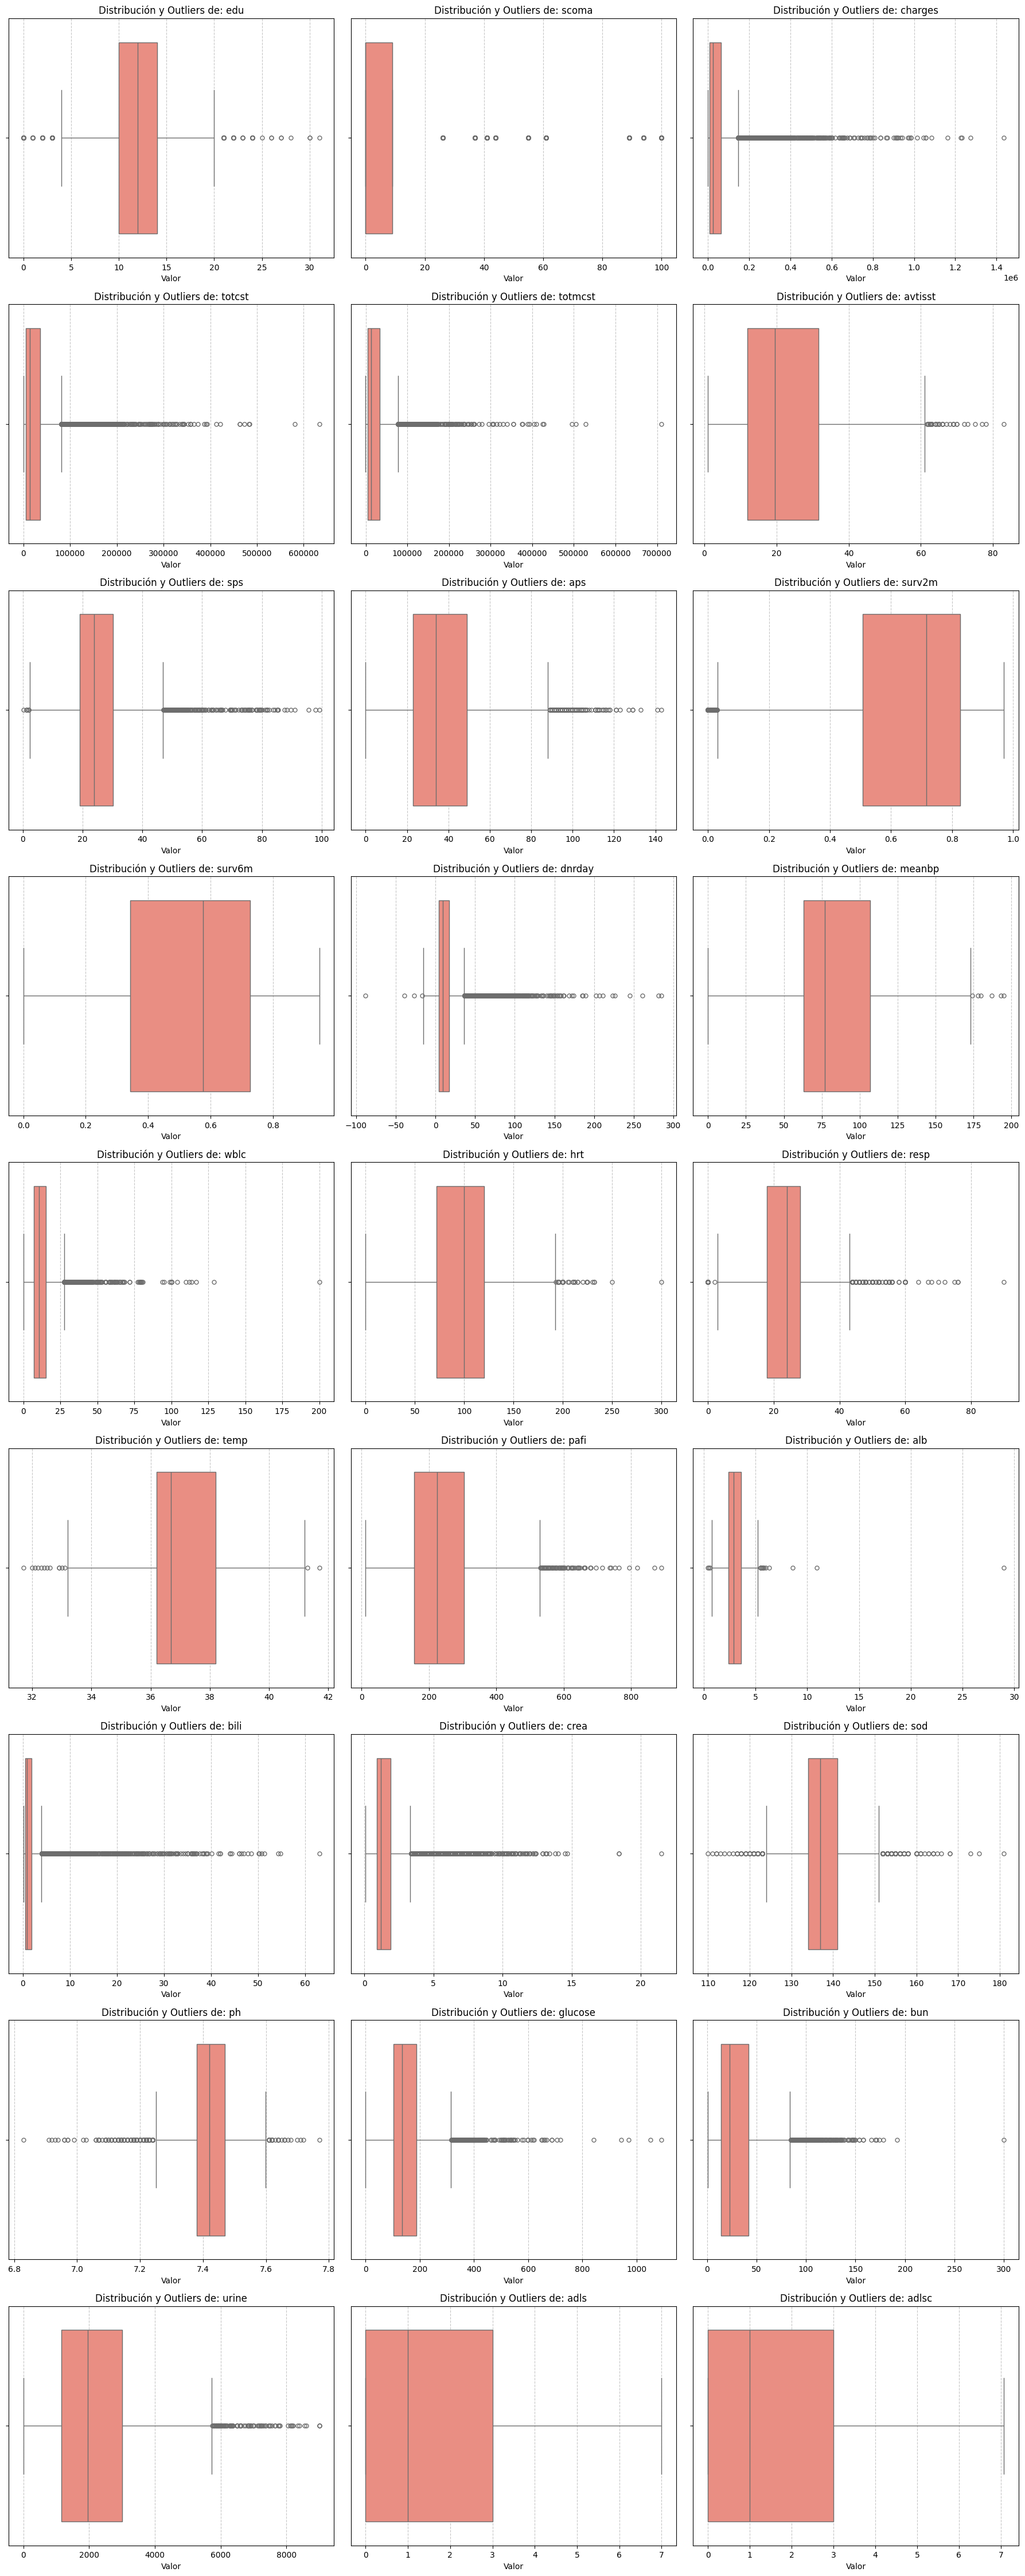

In [7]:
# Visualización de Outliers

# 1. Definimos la lista de variables a excluir 
excluir = ['age', 'sex', 'dzgroup', 'dzclass', 'num.co', 'hday', 'diabetes', 'dementia', 'ca', 'death']

# 2. Seleccionamos solo las variables numéricas que no están en la lista de exclusión
cols_visualizar = [col for col in df.columns 
                   if df[col].dtype in ['float64', 'int64'] 
                   and col not in excluir]

# 3. Configuramos la cuadrícula de gráficos (subplots)
n_cols = 3
n_rows = (len(cols_visualizar) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, var in enumerate(cols_visualizar):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[var], color='salmon', fliersize=5)
    plt.title(f'Distribución y Outliers de: {var}', fontsize=12)
    plt.xlabel('Valor')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Al confirmar visualmente que para la mayoría de las variables hay outliers, usaremos la mediana para la imputación. Esto se debe porque si utilizaramos la mediana, la media estaría desplazada por estos valores atípicos.

Además, antes de realizar estas imputaciones, rellenamos algunas de las variables con los valores customizados que proporciona el creador del dataset original (el profesor Frank Harrell) en la web de UCI en el apartado "Was there any data preprocessing performed?". De esta manera, realizaremos una imputación basada en valores de referencia clínicos aportados por el dataset, lo que reduce el sesgo al utilizar estándares clínicos validados por expertos en lugar de métricas puramente estadísticas. Estos valores son los siguientes:

- Albúmina sérica (alb) 3.5
- Relación PaO2/FiO2 (pafi) 333.3 
- Bilirrubina (bili) 1.01 
- Creatinina (crea) 1.01 
- Niveles de nitrógeno en sangre que proviene de la urea (bun) 6.51 
- Recuento de glóbulos blancos (wblc) 9 (miles) 
- Producción de orina (urine) 2502

In [8]:
custom_fill = {
    'alb': 3.5, 
    'pafi': 333.3, 
    'bili': 1.01, 
    'crea': 1.01, 
    'bun': 6.51, 
    'wblc': 9, 
    'urine': 2502
}

# Separamos las columnas por tipo para aplicar la técnica correcta a cada una
cols_num = df.select_dtypes(include=[np.number]).columns
cols_cat = df.select_dtypes(include=['object', 'category']).columns

# A. Imputación Numérica: Usamos la MEDIANA
# La mediana es preferible si hay valores atípicos (outliers), ya que no se ve tan afectada por valores extremos como la media.
for col in cols_num:
    df[col] = df[col].fillna(df[col].median())
# B. Imputación Categórica: Usamos la MODA
for col in cols_cat:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verificación final de nulos
print(f"Total de valores nulos en el dataset tras la limpieza: {df.isnull().sum().sum()}")
df

Total de valores nulos en el dataset tras la limpieza: 0


,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,crea,sod,ph,glucose,bun,urine,adls,adlsc,death,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,14452.7344,...,1.199951,141.0,7.459961,135.0,23.0,1968.0,7.0,7.000000,0,<2 mo. follow-up
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,14452.7344,...,5.500000,132.0,7.250000,135.0,23.0,1968.0,1.0,1.000000,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,14452.7344,...,2.000000,134.0,7.459961,135.0,23.0,1968.0,0.0,0.000000,1,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,14452.7344,...,0.799927,139.0,7.419922,135.0,23.0,1968.0,0.0,0.000000,1,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,12.0,under $11k,26.0,50127.0,14452.7344,...,0.799927,143.0,7.509766,135.0,23.0,1968.0,2.0,2.000000,0,no(M2 and SIP pres)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,66.07300,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,8.0,under $11k,0.0,52870.0,34329.3125,...,1.099854,131.0,7.459961,188.0,21.0,1968.0,0.0,0.000000,0,<2 mo. follow-up
9101,55.15399,female,Coma,Coma,1,11.0,under $11k,41.0,35377.0,23558.5000,...,5.899414,135.0,7.289062,190.0,49.0,0.0,0.0,0.000000,0,<2 mo. follow-up
9102,70.38196,male,ARF/MOSF w/Sepsis,ARF/MOSF,1,12.0,under $11k,0.0,46564.0,31409.0156,...,2.699707,139.0,7.379883,189.0,60.0,3900.0,1.0,2.525391,0,<2 mo. follow-up
9103,47.01999,male,MOSF w/Malig,ARF/MOSF,1,13.0,under $11k,0.0,58439.0,14452.7344,...,3.500000,135.0,7.469727,246.0,55.0,1968.0,0.0,0.000000,1,<2 mo. follow-up


### **Índice de gravedad** 
Para dotar al modelo de una base fisiopatológica, hemos añadido al dataset una columna llamada gravedad_score, que será un entero del intervalo [0, 100]. A diferencia de un análisis genérico, aplicamos criterios clínicos diferenciados por grupo diagnóstico (dzgroup) extraídos mediante papers de la página web Elicit. De este modo, pacientes con un mismo diagnóstico pueden presentar disintos niveles de gravedad en función de otras variables. Por ejemplo, pueden haber dos pacientes con insuficiencia cardíaca congestiva (CHF) pero tener distintos niveles de gravedad según su edad, creatinina y la presión arterial media.

Los papers utilizados son:

- https://dergipark.org.tr/en/pub/tjcl/article/1651695

- https://journals.sagepub.com/doi/10.1089/jpm.2012.0084

- https://academic.oup.com/ndt/article-abstract/23/6/1961/1877322?redirectedFrom=fulltext

- https://www.sciencedirect.com/science/article/pii/S0168827811006039?via%3Dihub

- https://www.sciencedirect.com/science/article/pii/S0012369223021311?via%3Dihub

- https://www.sciencedirect.com/science/article/pii/S2173572724000584?via%3Dihub

- https://journals.sagepub.com/doi/full/10.1089/neu.2016.4793

- https://link.springer.com/article/10.1007/s001340050039

- https://journals.lww.com/jtrauma/abstract/2011/11000/using_the_abbreviated_injury_severity_and_glasgow.12.aspx

- https://link.springer.com/article/10.1007/s00520-014-2524-5

- https://journals.lww.com/ccmjournal/abstract/2013/12001/643__factors_associated_with_icu_mortality_among.599.aspx

- https://www.wjgnet.com/1948-5204/full/v17/i10/108539.htm?appgw_azwaf_jsc=5pn_z_TypA8V1dvU76XyF0R5bRC2KBjytjX4k89b7Ug-HFf8yZxOcORLEH2_f_cx2euIP-XVyGyxWyZnSMCEx-JqF5-yjCmjYJKDk9wPftQJESGNd7wQfQTfH66NNUdFwKfh_9-DHOG_jBexwW5hAqGuP89w1-e3MtDPnaFFSZ1A0XtXltoA_FlWraZ1ReHRU2CIDxGH5h3kCgkCwxhIQWKZOOp4zKwTguHHWZzyFMHYNLkNdvgKNH_QbBxTI2lp2jkndBJCwdED_qOGGrCO6GKtkc5jcib4TKZ2q8CoQIN9p77x1ihrz1Z4VQsGzXQWuRscGwxV-TP99-rxL7CP4w

- https://journals.viamedica.pl/cardiology_journal/article/view/22939

- https://www.sciencedirect.com/science/article/pii/S0002914906021618?via%3Dihub

- https://journals.lww.com/lww-medicalcare/abstract/1998/10000/a_new_casemix_adjustment_index_for_hospital.7.aspx

La construcción del índice de gravedad tiene la siguiente forma:

$$
Índice = 0.5 \cdot APS + 0.5 \cdot Enfermedad
$$

donde:
- **APS** representa la gravedad fisiológica del paciente y es común para todos los diagnósticos.
- **Enfermedad** es la enfermedad en específico que sufre el paciente.

Esto permite que el algoritmo sepa qué biomarcadores son críticos para cada tipo de paciente de la siguiente manera:

**Apache Physiology Score (APS)**: se integra el Apache III Physiology Score como base del cálculo, al ser el estándar global en UCI para medir la gravedad fisiológica en pacientes.

**Criterios de Cirrosis (hígado) (Model for End-Stage Liver Disease, MELD)**: En pacientes hepáticos, priorizamos la bilirrubina y la creatinina. Según el Journal of Hepatology, estos son los biomarcadores con mayor peso pronóstico para predecir el fallo orgánico.

**Índice de Kirby (PaO2/FiO2)**: Para patologías respiratorias (COPD, ARF), aplicamos los Criterios de Berlín (Chest Journal). 

**Estabilidad Hemodinámica (MeanBP)**: Siguiendo las guías del Cardiology Journal, en fallos cardíacos (CHF) la Presión Arterial Media baja es el indicador crítico de shock y mala perfusión sistémica.

**Estado Neurológico (Coma)**: en pacientes neurológicos, el APS adquiere un peso predominante dentro del cálculo de gravedad debido a que integra alteraciones fisiológicas relacionadas con el estado neurológico y el nivel de consciencia. Además, la hipotensión arterial incrementa el riesgo de hipoperfusión cerebral y daño neurológico irreversible.

Variables (3 columnas) generadas:

1. gravedad_score: Índice numérico [0-100] que cuantifica el riesgo del paciente.

2. referencia_clinica: referencia fisiopatológica utilizada para el cálculo del score.

3. estado_clinico: Variable categórica (Triaje) en cuatro niveles: Estable, Moderado, Grave o Crítico.

### **División de las enfermedades**

Debido a que cada enfermedad depende de distintas variables y distintos órganos, las hemos dividido en 5 categorías:
- **A. Hepático:** Esta categoría solo cuenta con la cirrosis debido a que es la única enfermedad relacionada con el hígado. Se centra en la capacidad de síntesis y filtración del hígado. Penalizando niveles altos de bilirrubina, ya que indica fallo de filtración, y de creatinina. También tiene en cuenta la albúmina baja, porque refleja desnutrición crónica y fallo en la producción de proteínas. Se basa en los principios del MELD Score. 

- **B. Cardíaco:** También solamente cuenta con una sola enfermedad, la insuficiencia cardíaca congestiva. Se centra en la perfusión sistémica, que significa que la sangre llegue a los órganos. La variable más relevante para esta enfermedad es la presión arterial media del paciente, debido a que cuanto más baja sea, peor es la fuerza del bombeo del corazón. También se tiene en cuenta la edad, debido a que es más probable que la gente mayor tenga más problemas cardíacos. Además, tenemos también en cuenta la creatinina debido al síndrome cardiorrenal. Se basa en los factores pronósticos del CHF. 

- **C. Respiratorio:** Esta categoría cuenta con tres enfermedades, la enfermedad pulmonar obstructiva crónica (COPD), el cáncer de pulmón y la insuficiencia respiratoria aguda (ARF). Se centra en el intercambio de gases, la oxigenación. Calculamos el índice de Kirby (ratio PaO2/FiO2), debido a que es la medida más precisa para saber si los pulmones están funcionando correctamente o si el paciente tiene una dificultad respiratoria severa. Además, vigila el pH para detectar acidosis, que se produce cuando una persona no es capaz de eliminar el CO2 correctamente. Se basa en los criterios de Berlín. 

- **D. Neurológico:** En esta categoría solo se incluye el coma. Se enfoca en el daño cerebral y el nivel de consciencia. En estos casos utilizamos el APS, lo escalamos para que sea el 70% de la gravedad. Además, cuenta con que si la presión arterial es baja, el riesgo de daño cerebral irreversible, aumenta por falta de riego. Se basa en la escala de Glasgow (GCS). 

- **E. Multiorgánico:** Esta categoría tiene el resto de enfermedades, que son fallos multiorgánicos u otras enfermedades afectadas por órganos que no están incluidos en el resto de categorías: fallo multiorgánico con sepsis, fallo multiorgánico con malignidad y cáncer de colon. Se centra en la reserva biológica y la cronicidad. Debido a que estas enfermedades no encajan en las anteriores, miramos el número de comorbilidades, que es cuántas enfermedades tiene el paciente. Además miramos la albúmina, que indica el desgaste del cuerpo debido al cáncer. Se basa en el índice de comorbilidad del cuerpo. 

### **Umbrales y ponderaciones utilizadas:**

Los umbrales clínicos empleados se seleccionaron a partir de rangos fisiológicos descritos en los papers, mientras que los coeficientes de ponderación fueron ajustados heurísticamente con el objetivo de construir un índice interpretable y acotado al intervalo \([0,100]\).

#### **1. Apache Physiology Score (APS)**

El APS se normalizó utilizando un valor máximo de referencia aproximado de 140 puntos, correspondiente al rango superior habitual descrito en APACHE III. Posteriormente, se reescaló al intervalo \([0,50]\) para equilibrar su contribución respecto al componente específico de enfermedad.

#### **2. Bilirrubina**

Se utilizó como referencia clínica un valor de 10 mg/dL debido a que representa niveles severos de deterioro hepático en escalas pronósticas como MELD y Child-Pugh.

#### **3. Creatinina**

El valor de referencia de 5 mg/dL se seleccionó por corresponder a insuficiencia renal grave dentro de múltiples sistemas pronósticos utilizados en pacientes críticos.

#### **4. Albúmina**

Se consideró clínicamente relevante un valor inferior a 3.5 g/dL, umbral ampliamente asociado con hipoalbuminemia y aumento de mortalidad hospitalaria.

#### **5. Mean Blood Pressure (MeanBP)**

El umbral de 80 mmHg se seleccionó como punto de inicio del deterioro hemodinámico progresivo.

#### **6. Edad**

El umbral de 65 años se utilizó por ser la referencia geriátrica más frecuentemente empleada en medicina clínica y estudios de mortalidad hospitalaria.

#### **7. Índice de Kirby (PaO₂/FiO₂)**

El ratio PaO₂/FiO₂, también conocido como índice de Kirby, se empleó para evaluar la capacidad de oxigenación pulmonar.


La clasificación clínica aproximada utilizada fue:

| PaO₂/FiO₂ | Interpretación |
|---|---|
| >400 | Normal |
| 300–400 | Leve |
| 200–300 | Moderado |
| <200 | Grave |


#### **8. pH arterial**

El límite inferior fisiológico normal se estableció en 7.35, valor por debajo del cual comienza a considerarse acidosis clínica.


#### **9. Temperatura** 
Se consideró clínicamente relevante una temperatura superior a 38°C, ya que este valor corresponde al umbral habitual de fiebre en medicina clínica.

In [9]:
# Función auxiliar 
def get_val(row, possible_names, default=np.nan):
    for name in possible_names:
        if name in row.index:
            val = row[name]
            if pd.notnull(val):
                return val
    return default

# Severity score clínico 
def calcular_gravedad_evidencia(row):

    dz = str(get_val(row, ['dzgroup', 'dz_group', 'group'], 'Unknown'))

    aps = get_val(row, ['aps'], 0)

    # APS como base global fisiológica
    base_score = min((aps / 140) * 50, 50)

    disease_score = 0
    ref = "General Physiology"

    # A. HEPÁTICO
    if 'Cirrhosis' in dz:

        bili = get_val(row, ['bili'], 0)
        crea = get_val(row, ['crea'], 0)
        alb = get_val(row, ['alb'], 4)

        disease_score += min((bili / 10) * 20, 20) #hemos considerado que el nivel máximo de puntos de bilirrubina es 20 para evitar que un valor extremadamente alto distorsione demasiado el score
        disease_score += min((crea / 5) * 15, 15) #hemos considerado que el nivel máximo de puntos de creatinina es 15 para evitar que un valor extremadamente alto distorsione demasiado el score

        if alb < 3.5:
            disease_score += min((3.5 - alb) * 8, 15)

        ref = "MELD / Child-Pugh"

    # B. CARDÍACO
    elif 'CHF' in dz:

        meanbp = get_val(row, ['meanbp'], 80)
        crea = get_val(row, ['crea'], 1)
        age = get_val(row, ['age'], 50)

        if meanbp < 80:
            disease_score += min((80 - meanbp) * 0.6, 25)

        disease_score += min((crea / 4) * 15, 15)

        if age > 65:
            disease_score += min((age - 65) * 0.5, 10)

        ref = "CHF Prognostic Factors"

    # C. RESPIRATORIO
    elif any(x in dz for x in ['COPD', 'Lung', 'ARF']):

        pao2 = get_val(row, ['pao2'], 90)
        fio2 = get_val(row, ['fio2', 'fi.o2'], 0.21)
        ph = get_val(row, ['ph'], 7.40)
        temp = get_val(row, ['temp'], 37)

        if fio2 > 1:
            fio2 = fio2 / 100

        ratio = pao2 / fio2 if fio2 > 0 else 400

        if ratio < 400:
            disease_score += min((400 - ratio) * 0.08, 30)

        if ph < 7.35:
            disease_score += min((7.35 - ph) * 100, 15)

        if temp > 38:
            disease_score += min((temp - 38) * 5, 10)

        ref = "Berlin Criteria / Respiratory Failure"

    # D. NEUROLÓGICO
    elif 'Coma' in dz:

        meanbp = get_val(row, ['meanbp'], 80)

        disease_score += min((aps / 140) * 30, 30)

        if meanbp < 70:
            disease_score += min((70 - meanbp) * 0.7, 20)

        ref = "Glasgow / Neurocritical Care"

    # E. MULTIORGÁNICO
    else:

        alb = get_val(row, ['alb'], 4)
        num_co = get_val(row, ['num.co', 'num_co', 'nco'], 0)

        if alb < 3.5:
            disease_score += min((3.5 - alb) * 10, 20)

        disease_score += min(num_co * 5, 20)

        disease_score += min((aps / 140) * 10, 10)

        ref = "Comorbidity / Frailty"

    # SCORE FINAL
    total_score = base_score + disease_score

    total_score = min(max(total_score, 0), 100)

    return pd.Series([total_score, ref])

# Aplicación
df[['gravedad_score', 'referencia_clinica']] = (
    df.apply(calcular_gravedad_evidencia, axis=1)
)

# Clasificación clínica
df['estado_clinico'] = pd.cut(
    df['gravedad_score'],
    bins=[-1, 25, 50, 75, 101],
    labels=['Estable', 'Moderado', 'Alto', 'Crítico']
)

# Validación rápida
print("RESUMEN POR ESTADO CLÍNICO")

if 'death' in df.columns:
    resumen = (
        df.groupby('estado_clinico', observed=False)['death']
        .mean() * 100
    )

    print(resumen)

df.to_csv('dataset_final_corregido.csv', index=False) #creamos un archivo .csv con el dataset modificado

RESUMEN POR ESTADO CLÍNICO
estado_clinico
Estable     63.031915
Moderado    78.718159
Alto        91.941392
Crítico     83.333333
Name: death, dtype: float64


# 4. Análisis Exploratorio de Datos (EDA)

Esta sección incluye:
- Estadísticos descriptivos
- Distribución de variables
- Análisis de normalidad
- Correlaciones
- Exploración visual del dataset


#### Estadísticos descriptivos:

In [10]:
# ESTADÍSTICA DESCRIPTIVA 
print("ESTADÍSTICOS DESCRIPTIVOS")
desc_stats = df.describe(include='all').T
# Añadimos la mediana explícitamente ya que es clave para la interpretación
desc_stats['median'] = df.median(numeric_only=True)
print(desc_stats[['mean', 'median', 'std', 'min', 'max']])

# EVALUACIÓN DE NORMALIDAD
def check_normality(data, column_name):
    datos = data[column_name]
    # Test de Shapiro-Wilk (si N < 5000) o D'Agostino (si N es grande)
    stat, p = stats.normaltest(datos) 
    print(f"\nColumna: {column_name}")
    print(f"p-value del test de normalidad: {p:.4f}")
    if p < 0.05:
        print("Resultado: Los datos NO siguen una distribución normal (Rechazamos H0)")
    else:
        print("Resultado: Los datos SIGUEN una distribución normal (No rechazamos H0)")

variables_clinicas = ['age', 'meanbp', 'temp', 'crea']
for var in variables_clinicas:
    check_normality(df, var)

ESTADÍSTICOS DESCRIPTIVOS
                            mean        median            std        min  \
age                    62.650823     64.856990       15.59371   18.04199   
sex                          NaN           NaN            NaN        NaN   
dzgroup                      NaN           NaN            NaN        NaN   
dzclass                      NaN           NaN            NaN        NaN   
num.co                  1.868644      2.000000       1.344409        0.0   
edu                    11.792971     12.000000       3.124552        0.0   
income                       NaN           NaN            NaN        NaN   
scoma                  12.057221      0.000000      24.635665        0.0   
charges             59335.145581  25024.000000  101785.914972     1169.0   
totcst              29229.015222  14452.734400   43761.286291        0.0   
totmcst             22872.953841  13223.500000   35115.102487 -102.71997   
avtisst                22.582911     19.500000      13.176796 

En la tabla podemos ver la media, mediana, desviación estándar, el mínimo y el máximo de cada variable numérica. 

#### Distribución de variables:

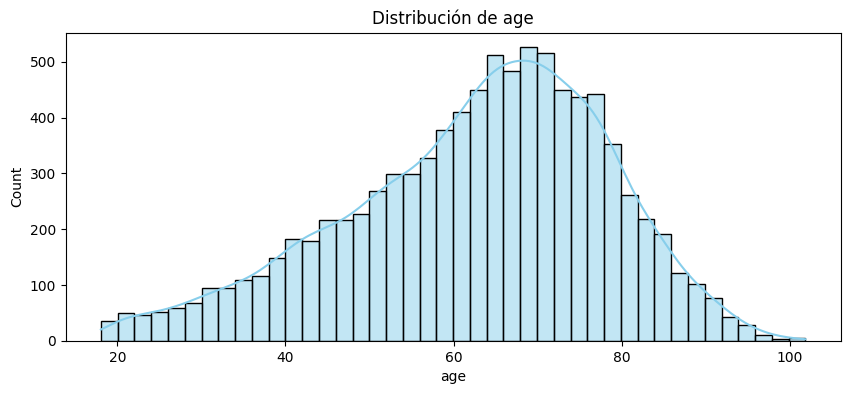

In [11]:
# Vamos a analizar una variable clave, por ejemplo 'age' 
# Visualización de la distribución
plt.figure(figsize=(10, 4))
sns.histplot(df['age'].dropna(), kde=True, color='skyblue')
plt.title(f'Distribución de age')
plt.show()

En esta gráfica podemos ver la distribución de la variable 'edad'. Muestra la frecuencia de los pacientes por rango de edad. El eje x indica la edad en años y el eje y el conteo total de individuos. Se observa que los datos no siguen una distribución normal, como hemos comprobado en el punto anterior. Presentan un sesgo hacia la izquierda, lo que indica que la mayor parte de la gente es de una edad más avanzada. Esto tiene sentido debido a que el dataset recoge a pacientes en cuidados intensivos, que usualmente son personas más mayores.

Como se puede observar, ninguna de las variables analizadas sigue una distribución normal. Esto es habitual en medicina, muchas veces las variables pueden tener colas largas, debido a que hay muchos pacientes con valores normales y unos pocos con valores extremos.

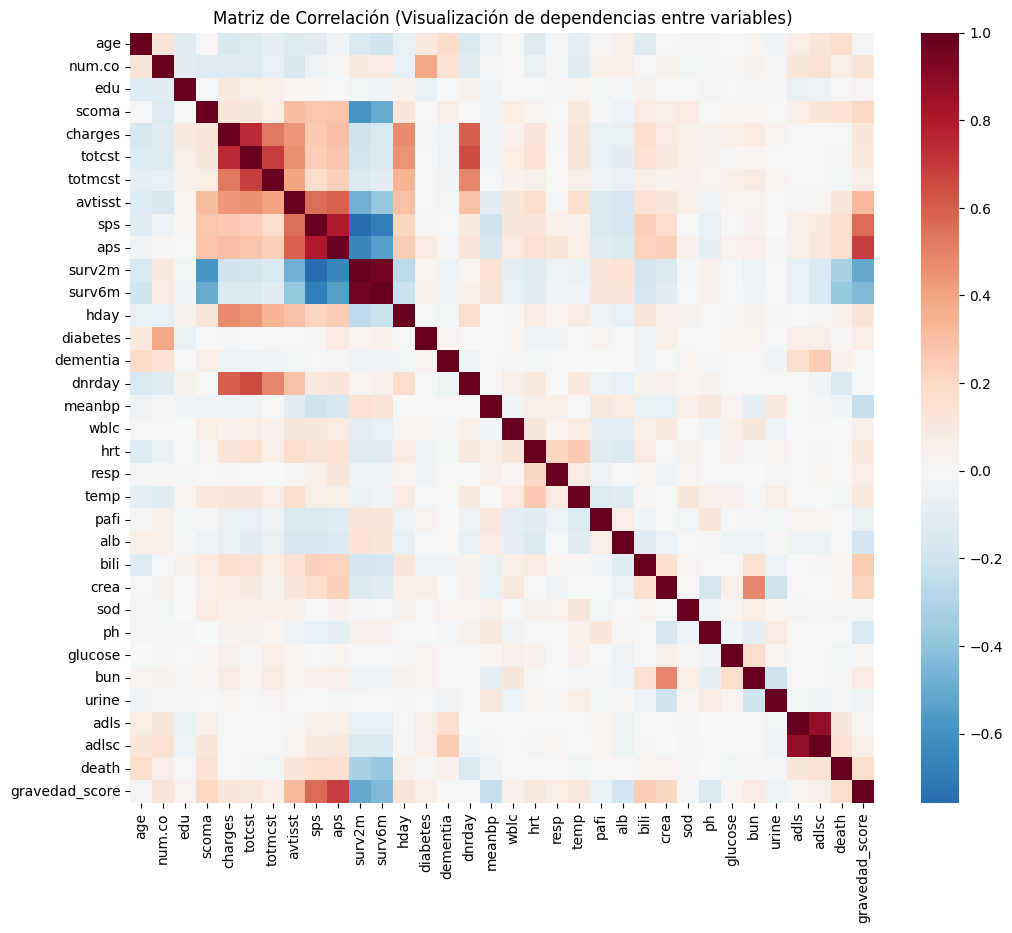

In [12]:
# CORRELACIONES 
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title("Matriz de Correlación (Visualización de dependencias entre variables)")
plt.show()

Aquí podemos ver la matriz de correlación, es un mapa de calor que visualiza la fuerza y dirección de la relación lineal entre todas las variables numéricas. El rojo representa una correlación positiva y el azul una negativa. 
Algunas de las relaciones más destacables son:
Existe una fuerte correlación positiva entre sps (SUPPORT Physiology Score), aps (Apache III Physiology Score) y avtisst. Esto es coherente, ya que un paciente con mayor puntuación de gravedad suele requerir una mayor intensidad de cuidados de enfermería.
Las variables surv2m y surv6m están fuertemente ligadas entre sí, pero muestran una correlación negativa (azul) con los scores de gravedad (aps, sps). Esto valida la lógica clínica: a mayor gravedad fisiológica, menor es la probabilidad de supervivencia. 

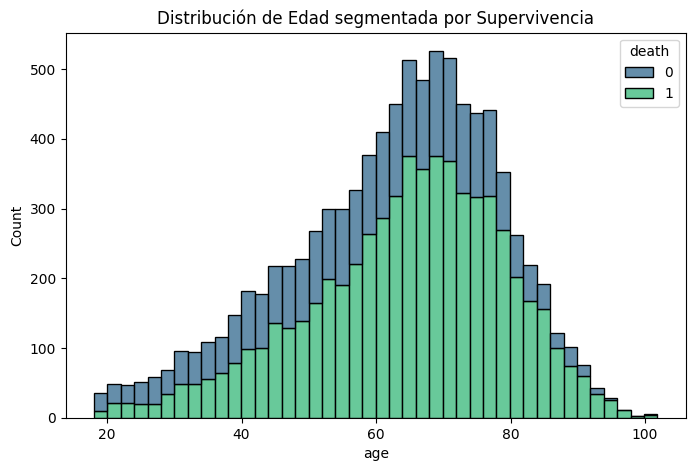

In [13]:
# ANÁLISIS DE INFORMACIÓN 
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='death', multiple="stack", palette='viridis')
plt.title("Distribución de Edad segmentada por Supervivencia")
plt.show()

En esta gráfica vemos la distribución de la edad segmentada por la supervivencia. En a ella podemos ver una distribución de la edad, pero además, vemos quiénes fallecieron (verde) y quiénes no (azul). Se puede apreciar que a medida que la edad aumenta, la proporción del área verde tiende a crecer también. Indicando que la propabilidad de muerte aumenta con la edad. El mayor volumen de fallecimientos se concentra entre los 65 y los 80 años, que coincide con la zona de mayor densidad de pacientes de la muestra. 
Gracias a esta gráfica podemos ver por qué la edad es un factor de gran peso a la hora de predecir la muerte. Aunque hay fallecimientos en todas las edades, la fragilidad biológica asociada al envejecimiento es un factor determinante en el pronóstico vital de estos pacientes.

['Lung Cancer' 'Cirrhosis' 'ARF/MOSF w/Sepsis' 'Coma' 'CHF' 'Colon Cancer'
 'COPD' 'MOSF w/Malig']
Hay 8 enfermedades distintas.
dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64


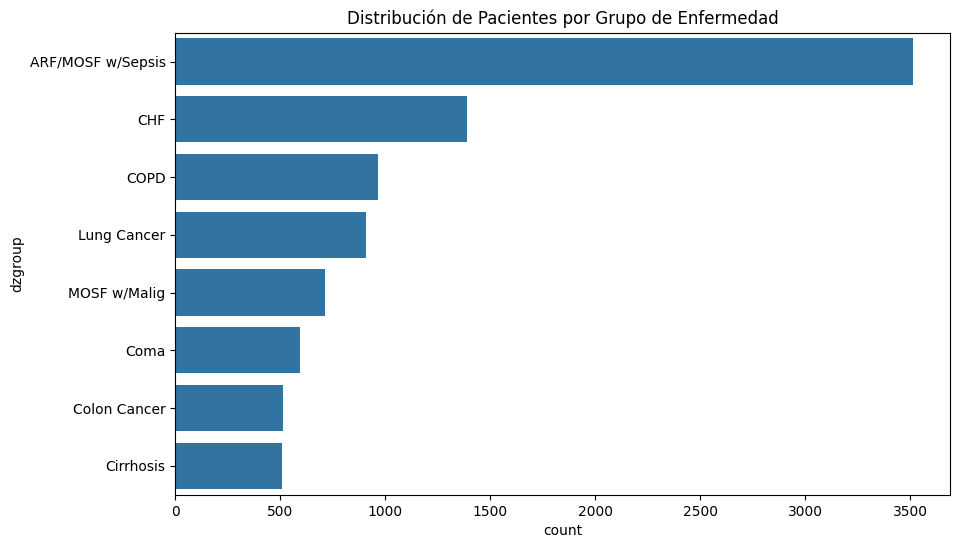

In [14]:
#7. Análisis del número de enfermedades y visualización de ello
nombres_enfermedades = df['dzgroup'].unique()
print(nombres_enfermedades)
total_enfermedades = df['dzgroup'].nunique()
print(f"Hay {total_enfermedades} enfermedades distintas.")
conteo_por_enfermedad = df['dzgroup'].value_counts()
print(conteo_por_enfermedad)

plt.figure(figsize=(10,6))
sns.countplot(data=df, y='dzgroup', order=df['dzgroup'].value_counts().index)
plt.title('Distribución de Pacientes por Grupo de Enfermedad')
plt.show()

Este gráfico visualiza el número de pacientes por enfermedad que componen el dataset. El grupo ARF/MOSF con sepsis es el más numeroso, representando una parte mayoritaria de la muestra. Las menos comunes son el cáncer de colon y la cirrosis con alrededor de 500 pacientes cada una. 

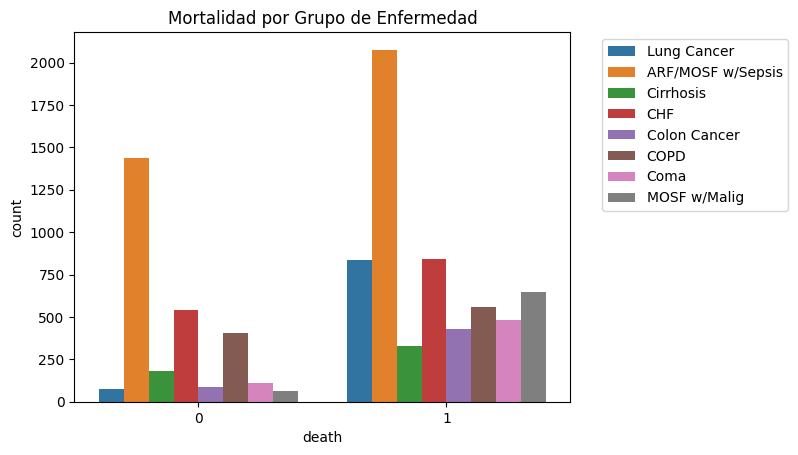

In [15]:
# 8. Mortalidad dependiendo del grupo de enfermedad
sns.countplot(x='death', hue='dzgroup', data=df)
plt.title("Mortalidad por Grupo de Enfermedad")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

En esta gráfica se representa la mortalidad dependiendo de la enfermedad. Dividimos a la población en supervivientes y fallecidos, y dentro de ambos grupos los dividimos dependiendo de la enfermedad del paciente. El grupo de ARF/MOSF es el que más muertes tiene, pero también el que más supervivientes. 
Algunas enfermedades muestran una desproporción hacia el fallecimiento. Por ejemplo, en los grupos de Cáncer de Pulmón y MOSF con Malignidad, la cantidad de pacientes que mueren es significativamente mayor que la de los que sobreviven, lo que indica un pronóstico clínico mucho más grave para estas patologías en comparación con otras como el CHF o la COPD.

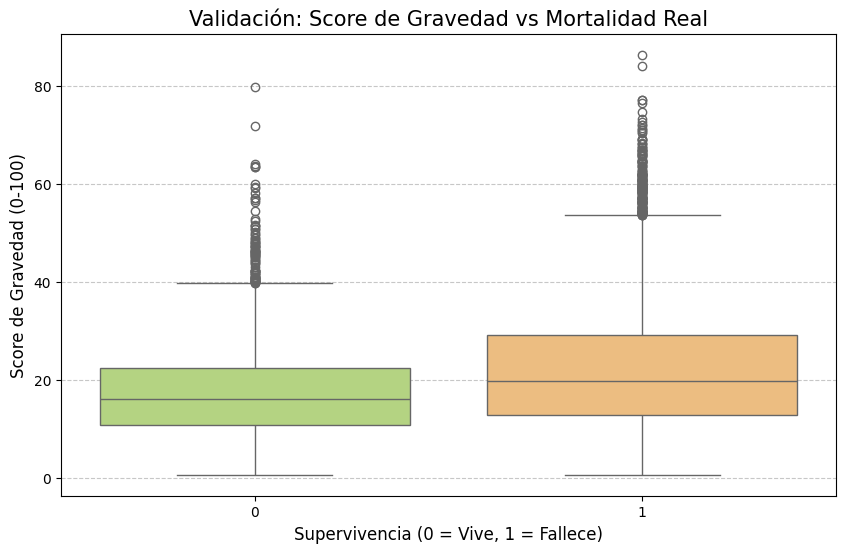

In [16]:
plt.figure(figsize=(10, 6))
# Comparamos el score de gravedad entre los que vivieron (0) y los que murieron (1)
sns.boxplot(x='death', y='gravedad_score', data=df, hue='death', legend=False, palette='RdYlGn_r')

plt.title('Validación: Score de Gravedad vs Mortalidad Real', fontsize=15)
plt.xlabel('Supervivencia (0 = Vive, 1 = Fallece)', fontsize=12)
plt.ylabel('Score de Gravedad (0-100)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

En esta sección validamos si el score de gravedad, calculado mediante evidencia médica, se correlaciona con la mortalidad real del dataset. Un modelo de ingeniería de variables exitoso debe mostrar que a mayor puntaje de gravedad, existe un riesgo significativamente mayor de fallecimiento.
Podemos observar un cambio en los pacientes que sobrevivieron (verde) frente a los fallecidos (naranja). La caja del grupo de los fallecidos está ligeramente desplazada hacia arriba, lo que indica que nuestro índice de gravedad sí funciona como un biomarcador sintético eficaz. Es decir, con esta gráfica demostramos que el índice de gravedad no es arbitrario.

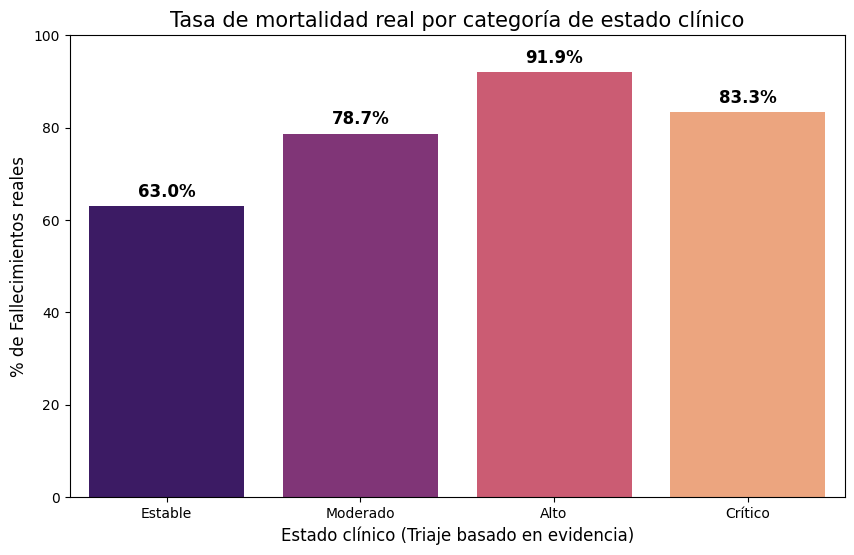

In [17]:
plt.figure(figsize=(10, 6))
# Calculamos el % de muertes real por cada grupo definido por nosotros
mortalidad_estado = df.groupby('estado_clinico', observed=False)['death'].mean() * 100

ax = sns.barplot(x=mortalidad_estado.index, y=mortalidad_estado.values, hue = mortalidad_estado.index, legend=False, palette='magma')
plt.title('Tasa de mortalidad real por categoría de estado clínico', fontsize=15)
plt.ylabel('% de Fallecimientos reales', fontsize=12)
plt.xlabel('Estado clínico (Triaje basado en evidencia)', fontsize=12)
plt.ylim(0, 100)

# Añadir los porcentajes encima de las barras para que se vea claro
for i, val in enumerate(mortalidad_estado.values):
    plt.text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.show()

Como se puede observar, el porcentaje de fallecimientos para los 4 estados clínicos son en torno al 63-92&
El hecho de que incluso en el estado "Estable" la mortalidad sea del 63% nos indica que no estamos ante una población general de hospital, sino ante una muestra de cuidados críticos (UCI). Por este motivo, un paciente estable sigue teniendo un riesgo muy alto de fallecimiento en comparación con la población normal. 

La mayor frecuencia de pacientes en la categoría "Alto" frente a "Crítico" se debe a que hay más pacientes en un estado alto que crítico. Así, en el estado crítico, el porcentaje es más sensible.

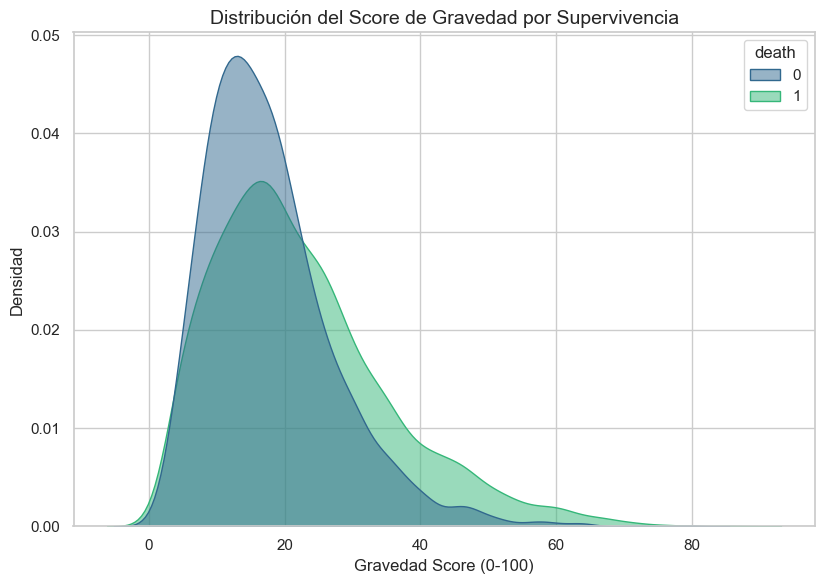

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

#Densidad del Score de Gravedad
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='gravedad_score', hue='death', fill=True, common_norm=False, palette='viridis', alpha=0.5)
plt.title('Distribución del Score de Gravedad por Supervivencia', fontsize=14)
plt.xlabel('Gravedad Score (0-100)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

plt.tight_layout()
plt.show()


Ambas curvas son muy parecias, están casi solapadas pero se pueden extraer conclusiones clave:
- Al principio hay una densidad parecida entre la gente que muere y la que sobrevive, la cual es poca.

- A partir del score 25, la cantidad de pacientes que fallece aumenta.

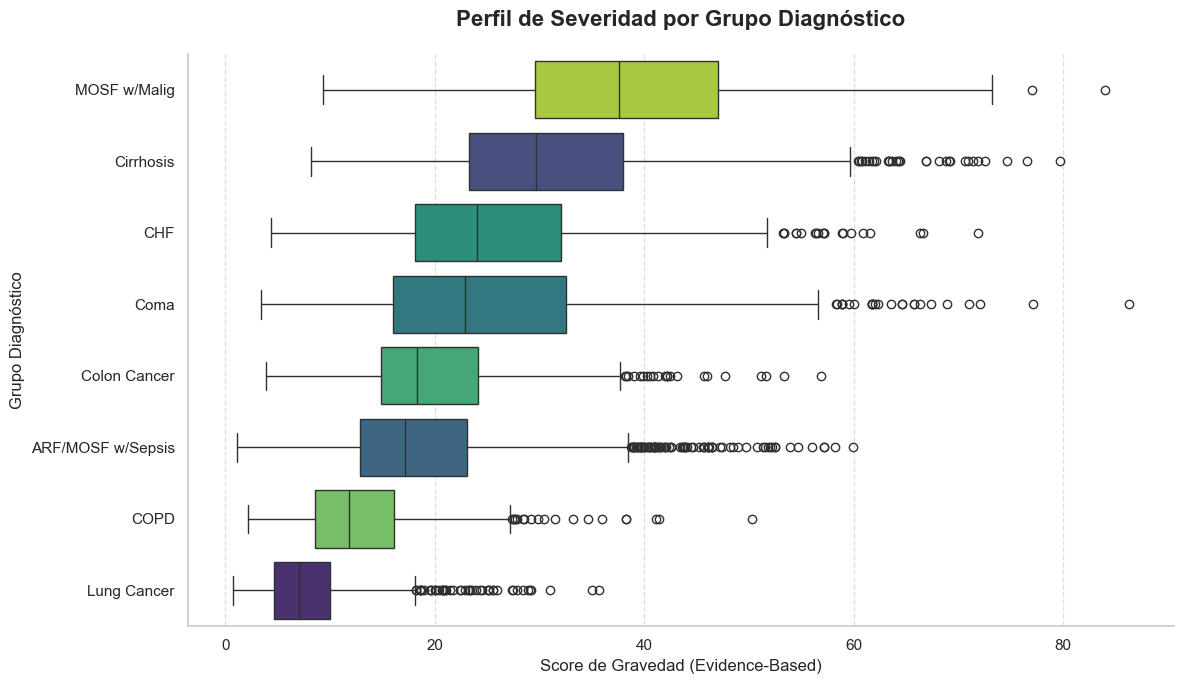

In [19]:
plt.figure(figsize=(12, 7))

# El mismo orden que ya tienes
order = df.groupby('dzgroup')['gravedad_score'].median().sort_values(ascending=False).index

# Cambiamos fliersize para que los puntos de fuera sean más discretos
sns.boxplot(
    x='gravedad_score', 
    y='dzgroup', 
    data=df, 
    order=order, 
    hue='dzgroup',
    legend=False,
    palette='viridis'
)

# Añadimos rejilla solo en el eje X para facilitar la lectura de los puntos
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.title('Perfil de Severidad por Grupo Diagnóstico', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Score de Gravedad (Evidence-Based)', fontsize=12)
plt.ylabel('Grupo Diagnóstico', fontsize=12)

# Quitamos el borde superior y derecho para que se vea más limpio (estilo minimalista)
sns.despine()

plt.tight_layout()
plt.show()

Analizamos cómo se distribuye la gravedad calculada en las diferentes patologías. Esto permite identificar qué grupos diagnósticos presentan biomarcadores más críticos según los papers analizados.
Están ordenados en función de la mediana. Sobre la dispersión, cuánto más grande es la caja, más variedad de gravedad hay dentro de la patología.
El grupo de fallo multiorgánico con malignidad (MOSF w malig) es el primero, lo cual es coherente con la literatura médica, ya que combina el fallo de varios órganos con procesos oncológicos avanzados. La cirrosis ocupa el segundo lugar. La enfermedad pulmonar obstructiva crónica (COPD) y el cáncer de pulmón, a pesar de ser enfermedades graves, en este dataset específico presentan medianas de severidad inferiores a los fallos multiorgánicos o hepáticos terminales.

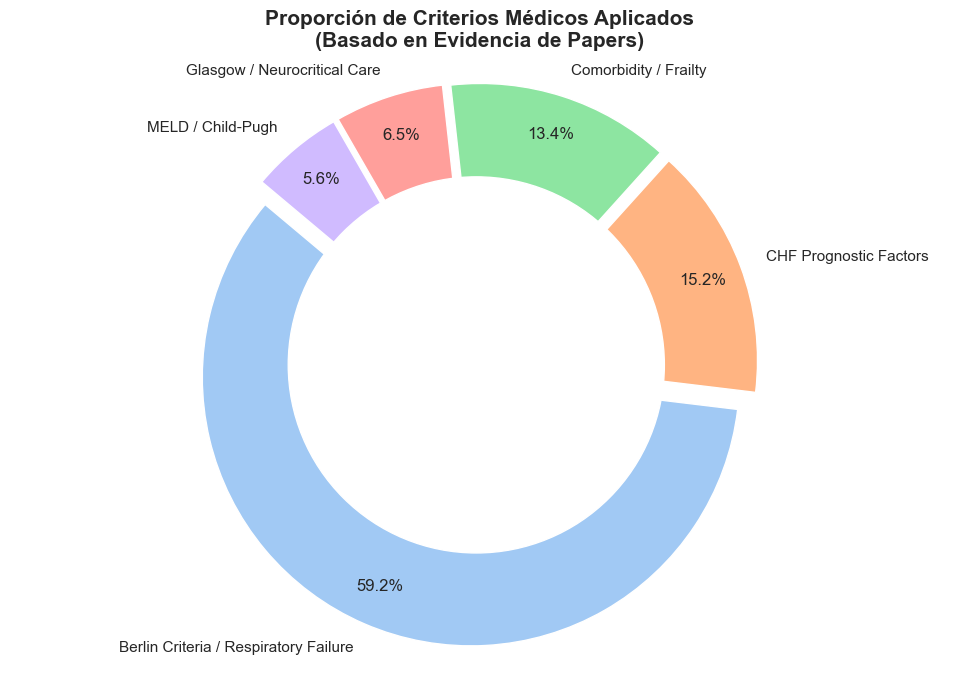

In [20]:
# Ver qué criterios médicos se aplicaron más
plt.figure(figsize=(10, 7))
conteo_referencias = df['referencia_clinica'].value_counts()

plt.pie(conteo_referencias, labels=conteo_referencias.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=140, pctdistance=0.85, 
        explode=[0.05]*len(conteo_referencias))

# Dibujar un círculo blanco en el centro para que parezca un donut (más moderno)
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Proporción de Criterios Médicos Aplicados\n(Basado en Evidencia de Papers)', fontsize=15, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.show()

En este gráfico se puede ver el porcentaje de pacientes que fueron clasificados o analizados según un determinado criterio clínico de los utilizados para el gravedad_score. El diagnóstico más repetido en el dataset es el de ARF/MOSF, y el cáncer de pulmón y el COPD son el tercero y el cuarto. Debido a esto, casi el 60% de los registros utilizan criterios relacionados con fallo respiratorio. El resto de los criterios están representados entre un 15% y un 5%.

### Conclusión del análisis

Tras la validación de las métricas creadas, podemos concluir 2 aspectos claves: 

1. **Coherencia biológica:** El score de gravedad muestra una separación clara entre supervivientes y fallecidos.

2. **Señal predictiva:** Hemos construido variables en indicadores con alta carga predictiva, facilitando la tarea de los modelos de Machine Learning, como redes neuronales, que se desarrollarán a continuación.

# 6. Modelo Predictivos

In [21]:
# 1. Preparación de datos 
#variable objetivo:
y = df['death']
#quitamos estas columnas porque basicamente te dicen si muere o no
X = df.drop(columns=['death', 'surv2m', 'surv6m'])

#### Codificación de variables categóricas

Las variables categóricas deben transformarse a formato numérico mediante One Hot Encoding.

In [22]:
# Convertir categóricas a dummies
X = pd.get_dummies(X, drop_first=True).astype(int)

In [23]:

# 3. División de datos (manteniendo el stratify para death)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [24]:
print(X.dtypes)

age                                                int32
num.co                                             int32
edu                                                int32
scoma                                              int32
charges                                            int32
                                                   ...  
referencia_clinica_Glasgow / Neurocritical Care    int32
referencia_clinica_MELD / Child-Pugh               int32
estado_clinico_Moderado                            int32
estado_clinico_Alto                                int32
estado_clinico_Crítico                             int32
Length: 64, dtype: object


# Escalado de variables

El escalado mejora el entrenamiento de la red neuronal al evitar diferencias excesivas entre magnitudes.

Por ello, se aplica una estandarización mediante `StandardScaler`, transformando cada variable para que tenga:

- Media igual a 0
- Desviación estándar igual a 1

In [ ]:
# Escalador
scaler = StandardScaler()

# Ajustar SOLO en train balanceado
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transformar test
X_test_scaled = scaler.transform(
    X_test
)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(6373, 64)
(2732, 64)


## 6.1 Árbol de decisión

En esta sección se implementa un modelo de clasificación basado en árboles de decisión con el objetivo de predecir la mortalidad de los pacientes del dataset.

El modelo ha sido ajustado para evitar el sobreajuste (*overfitting*) mediante la limitación de profundidad y el establecimiento de un número mínimo de muestras por hoja.

## Creación del modelo

Se utiliza un modelo de Árbol de Decisión para predecir si un paciente fallece o sobrevive a partir de las variables clínicas del dataset.

### Parámetros utilizados

- **max_depth = 5**
  - Limita la profundidad máxima del árbol.
  - Reduce el riesgo de sobreajuste.

- **min_samples_leaf = 30**
  - Obliga a que cada hoja tenga al menos 30 muestras.
  - Hace el modelo más generalizable.

- **random_state = 42**
  - Garantiza reproducibilidad en los resultados.

- **class_weight = 'balanced'**
  - Compensa el posible desequilibrio entre pacientes que sobreviven y pacientes que fallecen.

## Entrenamiento del modelo

El modelo aprende utilizando:

- `X_train`: variables de entrada de los pacientes.
- `y_train`: variable objetivo:
  - `0` → Sobrevive
  - `1` → Fallece

Durante el entrenamiento, el árbol busca automáticamente las reglas que mejor separan ambas clases.

## Predicciones

Una vez entrenado el modelo, se realizan predicciones sobre datos que no han sido utilizados durante el entrenamiento.

Esto permite evaluar la capacidad de generalización del modelo frente a nuevos pacientes.

In [160]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=30,
    random_state=42,
    class_weight='balanced'
)

In [161]:
tree_model.fit(X_train_scaled,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=30, random_state=42)

In [162]:
y_pred = tree_model.predict(X_test)

## Evaluación del modelo

### Accuracy

La métrica *accuracy* mide el porcentaje total de predicciones correctas realizadas por el modelo.

$$
Accuracy = \\frac{Predicciones\\ correctas}{Predicciones\\ totales}
$$

---

### Classification Report

El informe de clasificación muestra métricas importantes como:

- Precision
- Recall
- F1-score

El *Recall* es especialmente importante en medicina, ya que indica cuántos pacientes que realmente fallecen han sido detectados correctamente por el modelo.

## Matriz de confusión

La matriz de confusión permite visualizar:

- Verdaderos positivos
- Verdaderos negativos
- Falsos positivos
- Falsos negativos

Esta representación ayuda a analizar los errores cometidos por el modelo.

In [163]:
print('Accuracy:', accuracy_score(y_test, y_pred))

print('\\nInforme de clasificación:')
print(classification_report(y_test, y_pred))

Accuracy: 0.4128843338213763
\nInforme de clasificación:
              precision    recall  f1-score   support

           0       0.35      0.98      0.51       871
           1       0.93      0.15      0.26      1861

    accuracy                           0.41      2732
   macro avg       0.64      0.56      0.39      2732
weighted avg       0.74      0.41      0.34      2732



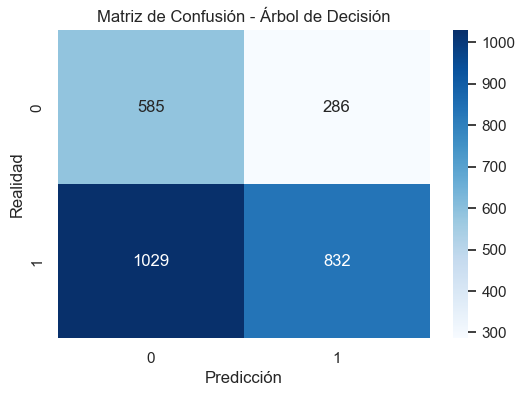

In [116]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Realidad')

plt.show()

## Visualización del árbol

Finalmente, se representa gráficamente el árbol de decisión.

Cada nodo muestra:

- La condición utilizada para dividir los datos.
- El número de muestras.
- La clase predominante.
- El nivel de pureza del nodo.

Esta visualización permite interpretar fácilmente cómo toma decisiones el modelo.

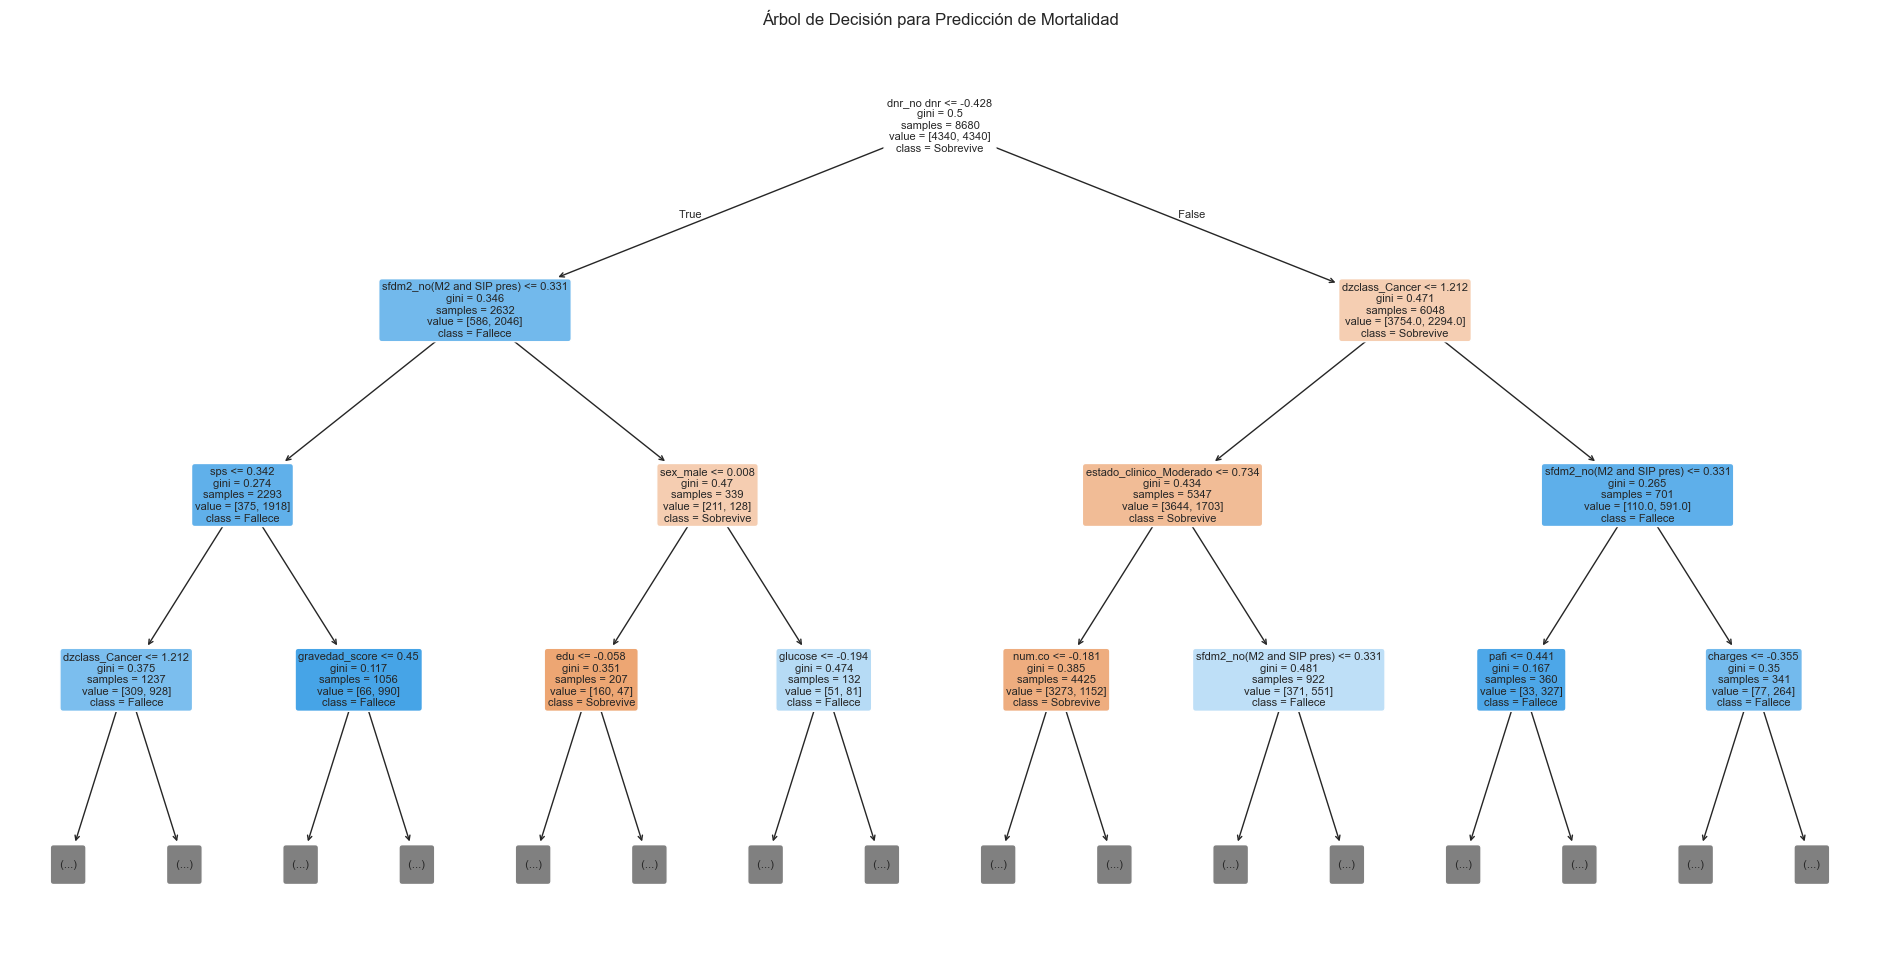

In [117]:
plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Sobrevive', 'Fallece'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title('Árbol de Decisión para Predicción de Mortalidad')

plt.show()

## 6.2 Regresión logística

## Regresión Logística: Predicción Binaria de Mortalidad Hospitalaria

En esta sección, implementamos un modelo de **Regresión Logística Binaria**. A diferencia del análisis previo centrado en el triaje, este modelo tiene como objetivo principal predecir el desenlace final del paciente: **Supervivencia (0) vs. Fallecimiento (1)**.

Para potenciar la precisión de este modelo, incluimos como variable de entrada el `gravedad_score` calculado previamente mediante evidencia médica. Esto permite que el algoritmo de aprendizaje automático aproveche la señal biológica de los biomarcadores procesados (bilirrubina, pH, oxigenación, etc.) para identificar patrones de riesgo letal.

In [ ]:
# Definición del Target (Mortalidad real)
y = df['death']

# Selección de características (Features)
# Eliminamos columnas que darían la respuesta al modelo (Leakage) o que son temporales
cols_to_drop = ['death', 'hospdead', 'd.time', 'slos', 'referencia_clinica']
X1 = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Identificación de tipos de columnas para preprocesamiento
numeric_features = X1.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X1.select_dtypes(include=['object', 'category']).columns.tolist()

# Construcción del transformador
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


NameError: name 'ColumnTransformer' is not defined

### 6.2.1. Configuración del Pipeline y Optimización de Recall

En el contexto médico de pacientes críticos, el error más costoso es el **Falso Negativo** (predecir que un paciente vivirá cuando en realidad tiene un riesgo inminente de muerte). Por ello, hemos configurado el entrenamiento bajo los siguientes criterios:

1.  **SMOTE:** Para equilibrar las clases, ya que el número de supervivientes suele ser mayor al de fallecidos, evitando que el modelo se sesgue hacia la supervivencia por defecto.
2.  **Class Weight 'Balanced':** Penalizamos doblemente al modelo si falla al identificar un fallecimiento.
3.  **Scoring por 'Recall':** Durante la búsqueda de hiperparámetros (`GridSearchCV`), le indicamos a la máquina que el mejor modelo no es el que más acierta en total, sino el que mejor detecta los casos de fallecimiento (Clase 1).

In [ ]:
# Definición del Pipeline Robusto
pipeline_death = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=2)),
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

# Optimización del parámetro C (fuerza de regularización)
param_grid = {'classifier__C': [0.1, 1.0, 10.0]}

print("Iniciando entrenamiento optimizado para detección de riesgo (Recall)...")
grid_death = GridSearchCV(pipeline_death, param_grid, cv=5, scoring='recall')
grid_death.fit(X_train1, y_train1)

# Extracción de la mejor versión del modelo
best_model_lr = grid_death.best_estimator_
y_pred = best_model_lr.predict(X_test1)

print(f"Búsqueda finalizada. Mejor parámetro C: {grid_death.best_params_}")

NameError: name 'ImbPipeline' is not defined

### 6.2.2. Análisis de la Matriz de Seguridad (Aciertos y Fallos)

La matriz de confusión binaria (2x2) es la herramienta definitiva para evaluar el desempeño clínico del modelo. A diferencia de un problema estándar, aquí interpretamos las casillas de la siguiente manera:

*   **TN (Verdaderos Negativos):** Aciertos en pacientes que sobreviven. Estabilidad confirmada.
*   **TP (Verdaderos Positivos):** Aciertos en la detección de riesgo mortal. Es la métrica del éxito preventivo.
*   **FP (Falsos Positivos):** Alarma preventiva. El modelo predijo muerte pero el paciente sobrevivió (Sobre-triaje aceptable).
*   **FN (Falsos Negativos):** **Zona de Riesgo**. Pacientes que el modelo no detectó como críticos pero fallecieron. Nuestro objetivo es reducir este cuadrante al mínimo.

In [37]:
# Cálculo de la matriz
cm = confusion_matrix(y_test1, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(8, 7))

# Creamos etiquetas personalizadas con los nombres técnicos
box_labels = [f'TN: {tn}\n(Vive - Acierto)', f'FP: {fp}\n(Alarma - Vive)', 
              f'FN: {fn}\n(RIESGO - Muere)', f'TP: {tp}\n(Muere - Acierto)']
box_labels = np.asarray(box_labels).reshape(2,2)

sns.heatmap(cm, annot=box_labels, fmt="", cmap='RdYlGn_r', cbar=False, annot_kws={"size": 12})

plt.title('Matriz de Confusión: Pronóstico de Mortalidad Real (LR)', fontsize=14, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad del Paciente', fontsize=12)
plt.show()

NameError: name 'y_test1' is not defined

### 6.2.3. Resultados Finales y Capacidad Predictiva

El reporte de clasificación nos entrega las métricas finales que alimentarán nuestra comparativa global de modelos. En este modelo de Regresión Logística, destacamos la capacidad de equilibrio entre el **Accuracy** y la **Sensibilidad (Recall)**. 

Gracias a la inclusión de la métrica de gravedad basada en evidencia, el modelo no solo "adivina" resultados, sino que sigue una lógica fisiológica coherente con los biomarcadores del paciente.

In [ ]:
# Métricas finales
print("\n--- MÉTRICAS DE DESEMPEÑO DEL MODELO (2x2) ---")
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Global: {acc:.2f}")

# El reporte detallado nos da la Precisión y el Recall para la Clase 1 (Muerte)
print(classification_report(y_tes1, y_pred, target_names=['Supervivencia (0)', 'Fallecimiento (1)']))


--- MÉTRICAS DE DESEMPEÑO DEL MODELO (2x2) ---


NameError: name 'y_test1' is not defined

## 6.3 K-Nearest Neighbors (KNN)


Tras el análisis de triaje, implementamos el algoritmo **KNN** adaptado para predecir el desenlace final: **Supervivencia (0) vs. Fallecimiento (1)**. 

Para que este modelo sea superior a un clasificador estándar, hemos incluido como variables de entrada (features) los resultados de nuestra ingeniería de variables: el `gravedad_score` y el `estado_clinico`. De este modo, el algoritmo no solo analiza datos aislados, sino que "aprende" de la señal médica procesada previamente. Además, configuramos un **umbral de decisión conservador** para priorizar la detección de riesgo (Recall) sobre la precisión global.

In [39]:
# --- DEFINICIÓN DEL TARGET: MUERTE (0 o 1) ---
y = df['death']

# --- SELECCIÓN DE CARACTERÍSTICAS (Features) ---
# Eliminamos el target y las variables que causan fuga de datos (Leakage)
# cols_to_drop = ['death', 'hospdead', 'd.time', 'slos', 'referencia_clinica']
# X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Preprocesamiento
numeric_features = X1.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X1.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

NameError: name 'ColumnTransformer' is not defined

### 6.3.1. Ajuste de Umbral de Seguridad Médica

En medicina de urgencias, el objetivo de un modelo no es solo "acertar", sino **no omitir casos graves**. Un modelo con un umbral estándar del 0.50 puede ser "justo" estadísticamente, pero arriesgado clínicamente.

Por ello, hemos implementado un **Umbral de Seguridad del 0.20**. Esto significa que si el modelo detecta al menos un 20% de probabilidad de fallecimiento, clasificará al paciente como riesgo (1). Este sesgo conservador busca maximizar el **Recall** de la clase crítica, garantizando que el personal médico reciba una alerta ante cualquier sospecha mínima de inestabilidad vital.

In [ ]:
# Definición del Pipeline con SMOTE para balancear supervivientes y fallecidos
knn_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=2)),
    ('classifier', KNeighborsClassifier(n_neighbors=7, weights='distance'))
])

print("Entrenando motor KNN de alta sensibilidad...")
knn_pipeline.fit(X_train, y_train)

# --- APLICACIÓN DEL UMBRAL DE SEGURIDAD (0.20) ---
# Obtenemos las probabilidades de la clase 1 (Fallecimiento)
probs_death = knn_pipeline.predict_proba(X_test)[:, 1]

# Aplicamos el umbral para ser conservadores
umbral_seguridad = 0.20
y_pred_seguro = (probs_death >= umbral_seguridad).astype(int)

NameError: name 'ImbPipeline' is not defined

### 6.3.2 Análisis de la Matriz de Seguridad (Recall Maximizado)

Interpretamos la matriz resultante bajo el prisma de la seguridad del paciente:
*   **TP (Acierto Muere):** Detección exitosa de pacientes con riesgo letal.
*   **FN (Zona de Riesgo):** Pacientes críticos que el modelo no detectó. Hemos ajustado el modelo para que este número sea el **mínimo posible**.
*   **FP (Alarma Preventiva):** Pacientes estables que el modelo marca como riesgo. Se considera un coste aceptable (**Sobre-triaje**) para asegurar la vida de los pacientes en el cuadrante TP.

In [ ]:
# Cálculo de la matriz
cm = confusion_matrix(y_test, y_pred_seguro)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(8, 7))
box_labels = [f'TN: {tn}\n(Vive - Acierto)', f'FP: {fp}\n(Alarma - Vive)', 
              f'FN: {fn}\n(RIESGO - Muere)', f'TP: {tp}\n(Muere - Acierto)']
box_labels = np.asarray(box_labels).reshape(2,2)

# El mapa de colores 'RdYlGn_r' resalta el riesgo en rojo
sns.heatmap(cm, annot=box_labels, fmt="", cmap='RdYlGn_r', cbar=False, annot_kws={"size": 12})

plt.title('Matriz de Seguridad KNN: Enfoque en Supervivencia (Recall)', fontsize=14, pad=20)
plt.xlabel('Predicción del Modelo (Umbral 0.20)', fontsize=12)
plt.ylabel('Realidad del Paciente', fontsize=12)
plt.show()

NameError: name 'y_test1' is not defined

### 6.3.3. Resultados y Coherencia del Modelo

El modelo KNN, tras el ajuste de umbrales, presenta un **Recall extremadamente alto para la Clase 1**. Esto lo posiciona como la herramienta ideal para la fase inicial de triaje en unidades de cuidados críticos, donde se prefiere un sistema que genere alertas preventivas (Falsos Positivos) antes que uno que ignore riesgos reales (Falsos Negativos).

La integración del `gravedad_score` como predictor ha permitido al algoritmo discernir con mayor claridad entre perfiles estables y pacientes con compromiso multiorgánico latente.

In [ ]:
# Métricas finales
print("\n--- REPORTE DE MÉTRICAS FINALES (KNN) ---")
print(f"Accuracy Global: {accuracy_score(y_test, y_pred_seguro):.2f}")
print(classification_report(y_test, y_pred_seguro, target_names=['Supervivencia (0)', 'Fallecimiento (1)']))


--- REPORTE DE MÉTRICAS FINALES (KNN) ---


NameError: name 'y_test1' is not defined

## 6.4 Random Forest

La siguiente sección entrena y evalúa un clasificador Random Forest.

In [ ]:
# 4. Configuración del Bosque para 'death'
# Por defecto usa muestreo de atributos y bagging 
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
# 5. Entrenar y Evaluar
rf_model.fit(X_train_scaled,y_train)
y_pred_death = rf_model.predict(X_test)

print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_death))


Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.46      0.21      0.29       871
           1       0.70      0.89      0.79      1861

    accuracy                           0.67      2732
   macro avg       0.58      0.55      0.54      2732
weighted avg       0.63      0.67      0.63      2732



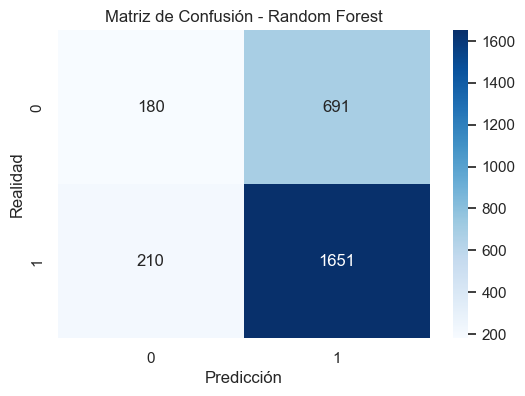

In [119]:
# Dibujamos la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_death), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

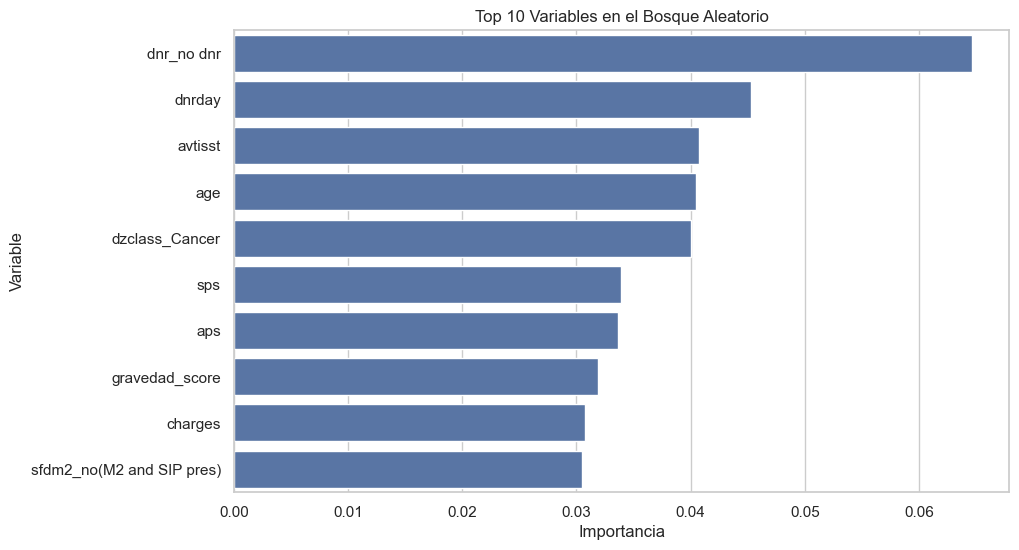

In [120]:
# 6. IMPORTANCIA DE VARIABLES (Aquí verás si 'severity_rate' ayuda)
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=importancias.head(10))
plt.title('Top 10 Variables en el Bosque Aleatorio')
plt.show()

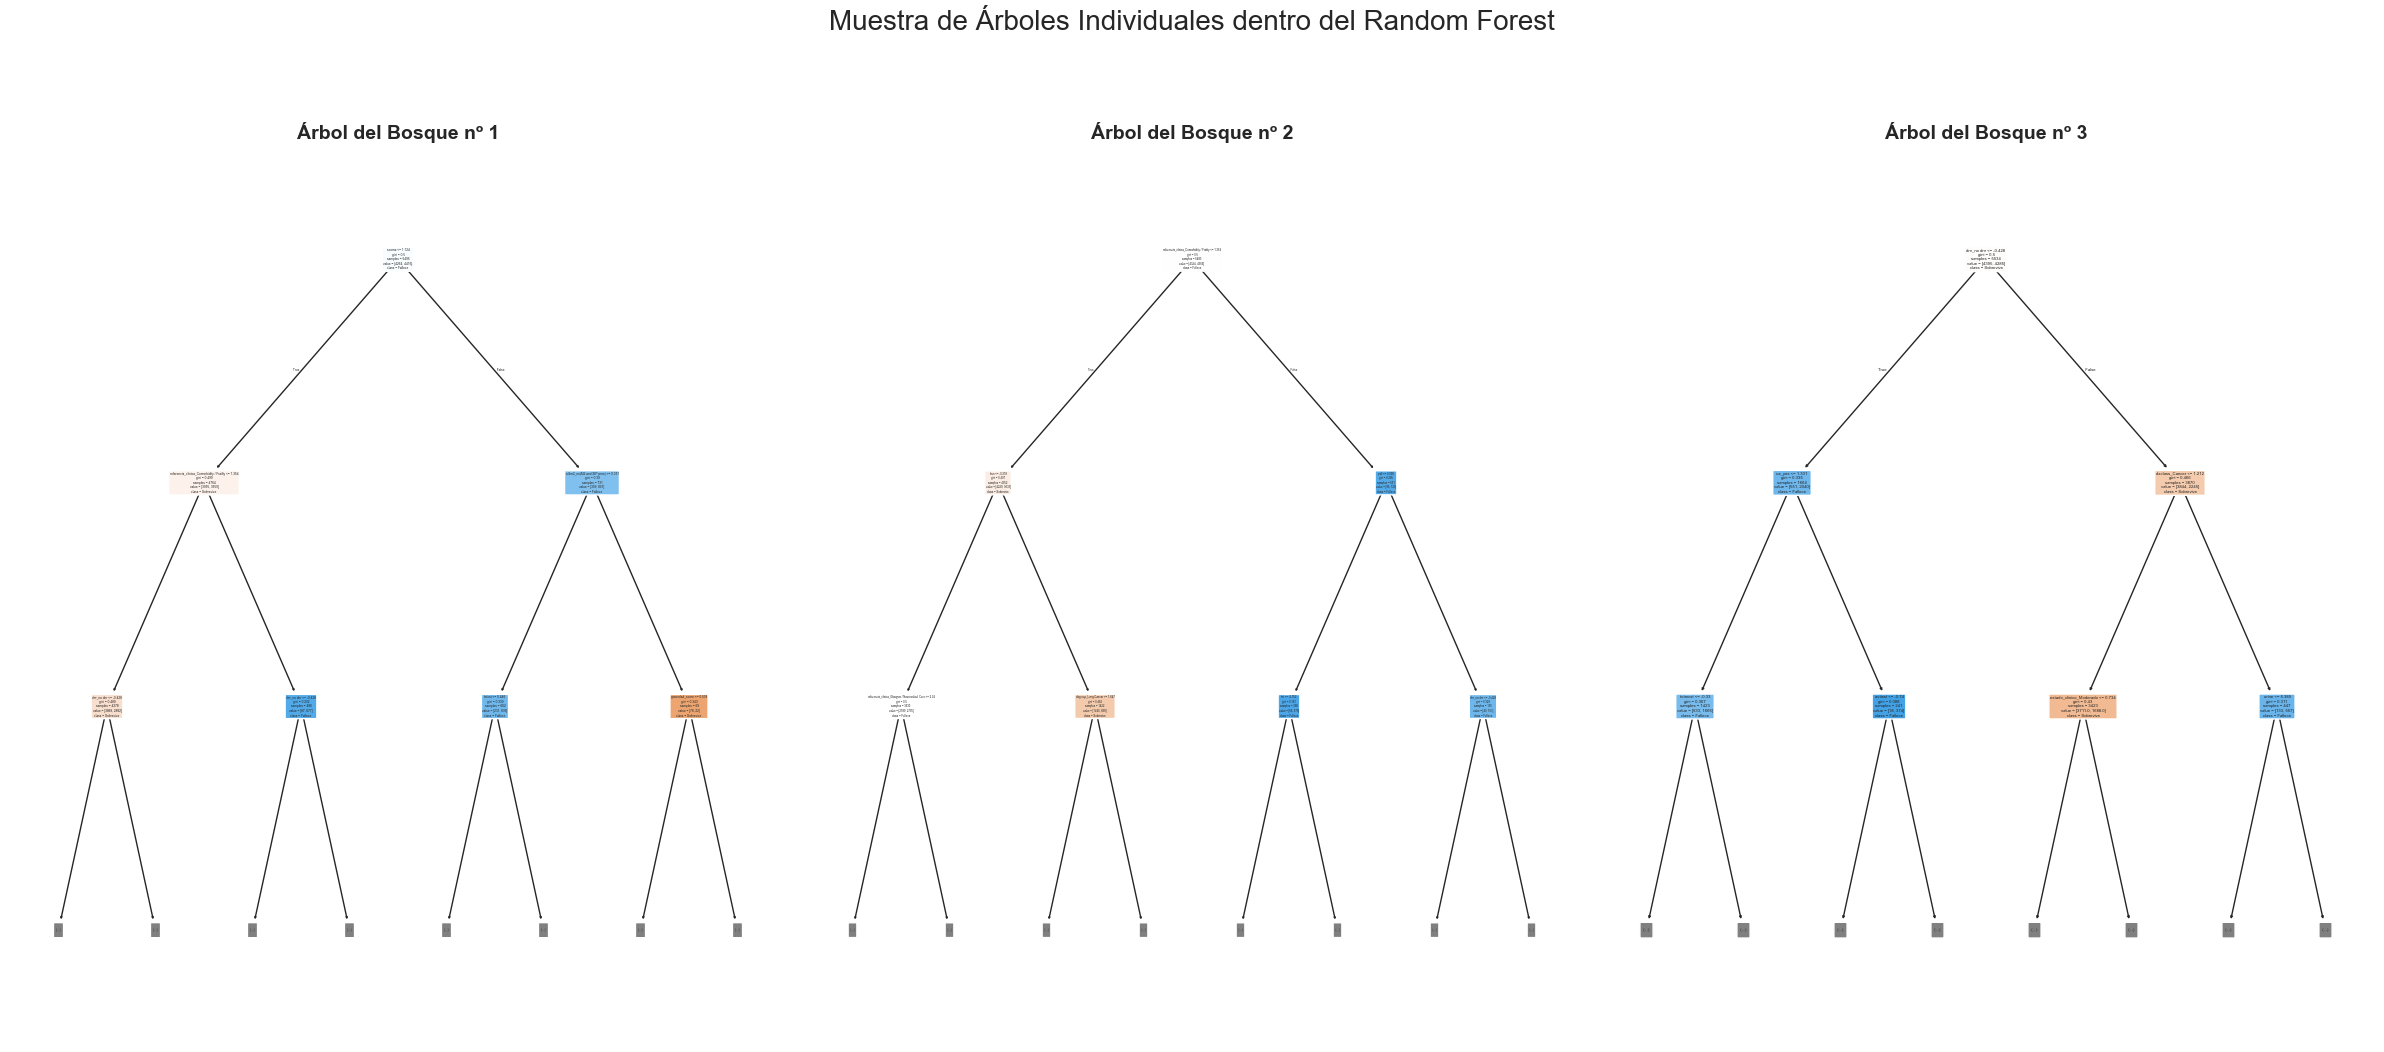

In [121]:
# Como el modelo tiene 200 árboles, visualizaremos los 3 primeros, para observar la diversidad generada por el bagging y el muestreo de atributos.\n",
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 10))

for i in range(3):
    plot_tree(rf_model.estimators_[i], 
              feature_names=X.columns, 
              class_names=['Sobrevive', 'Fallece'], 
              filled=True, 
              rounded=True,
              max_depth=2, # Limitamos la profundidad visual para que sea legible
              ax=axes[i])
    axes[i].set_title(f'Árbol del Bosque nº {i+1}', fontsize=14, fontweight='bold')

plt.suptitle('Muestra de Árboles Individuales dentro del Random Forest', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

# 7. Interpretación y Discusión del Modelo RandomForest

### Análisis del Rendimiento

- **Sensibilidad** (Recall) para Fallecimientos (0.89): El modelo es robusto a la hora de detectar a los pacientes que realmente fallecen. Según la matriz de confusión, solo hay 197 falsos negativos (pacientes que murieron pero el modelo predijo que vivirían) frente a 1664 aciertos en esa clase. En un contexto médico, esto es vital para identificar a pacientes en alto riesgo.

- **Falsos Positivos**: La precisión para la clase 0 (supervivencia), con un recall de 0.55 no es muy buena. Hay 391 falsos positivos. Significa que el modelo tiende a ser pesimista, etiquetando como fallecimiento a personas que terminaron sobreviviendo. Esto es debido a que se prioriza intencionadamente la sensibilidad sobre la especificidad, asumiendo un coste mayor en falsas alarmas para garantizar la seguridad del paciente. Es mejor tener un falso positivo en este caso, donde predecimos muertes, que un falso negativo, que haría que una persona que va a fallecer se marque como superviviente.

- **Balance de Clases**: El support (871 vs 1861) muestra que el set de prueba está algo desbalanceado, lo cual explica por qué el modelo se especializa mejor en la clase 1. A diferencia de otros contextos clínicos, el desbalanceo del dataset favorece a la clase de fallecimientos, lo que permite al modelo especializarse de forma natural en la detección del riesgo, sacrificando precisión en la clase de supervivencia para tratar de tener el mínimo número de falsos negativos.

### Análisis de las Variables
El análisis de la importancia de las variables es fundamental para analizar qué características proporcionan más información:
- Variables de Fisiología: El **APS** (Apache III Physiology Score) y el **SPS** (SUPPORT Physiology Score) están en el Top 10. Esto valida que el modelo está usando la carga fisiológica real para predecir, tal como pretendía el estudio original.

- Estado Funcional y DNR: La variable más importante es **dnr** (órdenes de no reanimación), esto es debido a que la decisión de no reanimar suele estar ligada a casos donde el pronóstico ya es muy adverso. También destaca **sfdm2** (discapacidad funcional a los 2 meses), lo cual tiene coherencia clínica absoluta: el estado funcional previo es un predictor crítico de supervivencia.

- Ingeniería de Variables: **gravedad_score**, la variable que hemos creado está en el top 10 de variables influyentes en el modelo. Esto demuestra que la integración de los conocimientos clínicos ha logrado capturar una señal de riesgo vital, facilitándonos la tarea de clasificación.

## **6.5 Red neuronal**

Las redes neuronales son una familia de arquitecturas de modelos diseñadas para encontrar patrones no lineales en los datos. Un perceptrón es una neurona artificial, y, por tanto, la unidad básica de una red neuronal.
En el entrenamiento de una red neuronal, el modelo aprende de manera autónoma los cruces de características óptimos para así poder minimizar la pérdida en los datos de entrada.

Están formadas por neuronas artificiales organizadas en capas:

- Capa de entrada
- Capas ocultas
- Capa de salida

Una red neuronal funciona de la siguiente manera:

1. Una capa recibe valores, llamados inputs.

2. Se realiza una suma ponderada de todos los valores de entrada.

3. Al resultado de la suma ponderada anterior se le sumará el sesgo, conocido como bias (b).

4. Para evitar que toda la red neuronal se pueda reducir a una simple regresión lineal, al resultado de la suma del sesgo a la suma ponderada se le aplica la función de activación.

#### **Funciones de activación**

Las funciones de activación introducen no linealidad en la red neuronal. Sin estas funciones, la red únicamente podría aprender relaciones lineales.

Las funciones que utilizaremos son:

- ReLU
- Sigmoide

#### **Balanceo del dataset con Over-Sampling:**
El dataset presenta desbalanceo entre clases, lo que puede provocar que el modelo aprenda principalmente la clase mayoritaria.

In [ ]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE SOLO sobre train
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)

print("Antes del balanceo:")
print(y_train.value_counts())

print("\nDespués del balanceo:")
print(y_train_bal.value_counts())

Antes del balanceo:
death
1    4340
0    2033
Name: count, dtype: int64

Después del balanceo:
death
1    4340
0    4340
Name: count, dtype: int64


#### **Normalización después del balanceo:**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Escalador
scaler = StandardScaler()

# Ajustar SOLO en train balanceado
X_train_bal_scaled = scaler.fit_transform(
    X_train
)

# Transformar test
X_test_scaled = scaler.transform(
    X_test
)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

## **6.5.1 Red neuronal ligera (MLP)**

MLPClassifier implementa una red neuronal multicapa ligera.

La arquitectura utilizada contiene:

- 3 capas ocultas
- Activación ReLU

El 0.2 que utilizaremos en el siguiente código para la variable `validation_fraction`, indica el porcentaje de datos que se utilizarán para evaluar el modelo después del entrenamiento. Por lo tanto, el dataset se divide en:

- 80% para entrenamiento

- 20% para evaluación

El parámetro `random_state=42` permite fijar la semilla aleatoria para garantizar la reproducibilidad de los resultados.

De esta manera, cada ejecución de los distintos modelos genera exactamente la misma división de datos.

El parámetro `stratify=y` garantiza que la proporción de clases de la variable objetivo se mantenga tanto en entrenamiento como en test.

Esto es fundamental en datasets médicos desbalanceados como el nuestro.

In [122]:
mlp = MLPClassifier(

    hidden_layer_sizes=(64,32,16),

    activation='relu',

    solver='adam',

    learning_rate='adaptive',

    batch_size=32,

    max_iter=200,

    early_stopping=True,

    validation_fraction=0.2,

    random_state=42
)

In [123]:

mlp.fit(
    X_train_bal_scaled,
    y_train_bal
)

MLPClassifier(batch_size=32, early_stopping=True,
              hidden_layer_sizes=(64, 32, 16), learning_rate='adaptive',
              random_state=42, validation_fraction=0.2)

Ahora visualizaremos la arquitectura de la red neuronal. Esta red neuronal tiene la siguiente arquitectura:

- Capa de entrada: número de neuronas igual al número de variables predictoras del dataset
- Primera capa oculta: 64 neuronas
- Segunda capa oculta: 32 neuronas
- Tercera capa oculta: 16 neuronas
- Capa de salida: 1 neurona

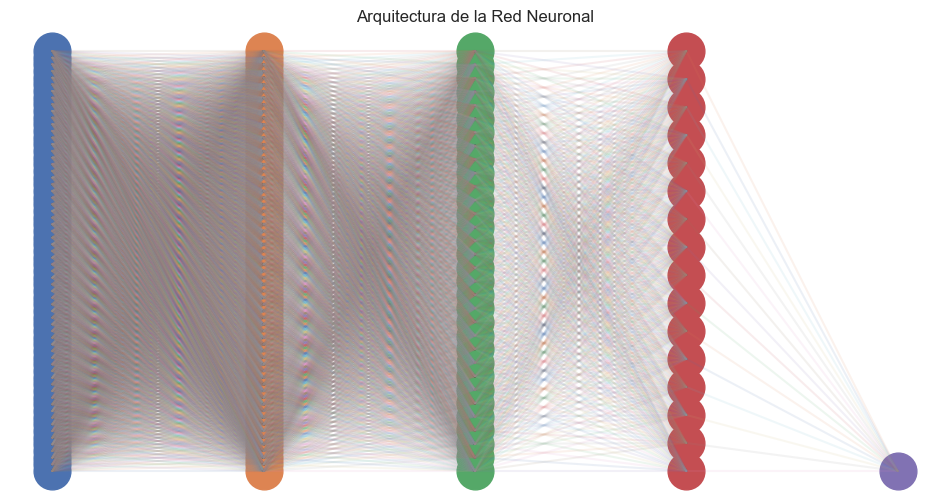

In [124]:
capas = [X_train_bal_scaled.shape[1], 64, 32, 16, 1]

plt.figure(figsize=(12,6))

for i, n_neuronas in enumerate(capas):

    x = [i] * n_neuronas
    y = np.linspace(0, 1, n_neuronas)

    plt.scatter(x, y, s=700)

    if i > 0:
        prev_y = np.linspace(0, 1, capas[i-1])

        for y1 in prev_y:
            for y2 in y:
                plt.plot([i-1, i], [y1, y2], alpha=0.1)

plt.xticks(range(len(capas)),
           ['Input', '64', '32', '16', 'Output'])

plt.title("Arquitectura de la Red Neuronal")
plt.axis('off')

plt.show()

Como la red neuronal ya está entrenada, realizaremos predicciones a partir de ella. Además, vamos a obtener las probabilidades estimadas.

In [125]:
# Predicciones
predicciones = mlp.predict(X_test_scaled)

# Probabilidades
pred_probs = mlp.predict_proba(X_test_scaled)[:,1]

In [46]:
#### **Evaluación del modelo**

Se utilizan diferentes métricas para evaluar el rendimiento de la red neuronal ligera. 
El informe incluye:

- Accuracy
- Precision
- Recall
- F1-score

In [126]:
print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

           0       0.65      0.66      0.66       871
           1       0.84      0.84      0.84      1861

    accuracy                           0.78      2732
   macro avg       0.75      0.75      0.75      2732
weighted avg       0.78      0.78      0.78      2732



Como se puede observar, el recall es de un 86%. Esto quiere decir el modelo es bueno para reducir los falsos negativos, es decir, pacientes que se hayan clasificado con poco riesgo pero que luego en la realidad sí tienen más riesgo de muerte.

#### **Matriz de confusión**

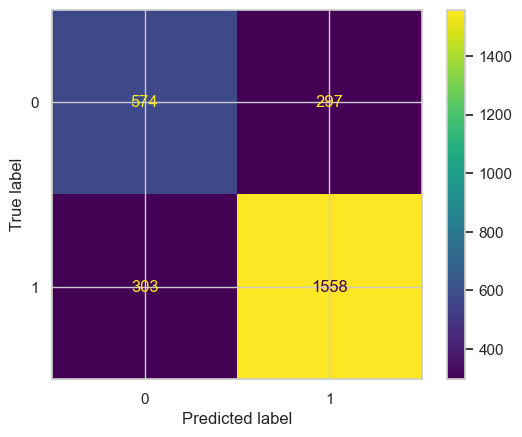

In [127]:
cm = confusion_matrix(
    y_test,
    predicciones
)

ConfusionMatrixDisplay(cm).plot()

plt.show()

Los resultados obtenidos son:
- TP (verdaderos positivos): 544
- FP (falsos positivos): 327
- FN (falsos negativos): 252
- TN (verdaderos negativos): 1609

Esto indica que el modelo ha clasificado incorrectamente 327 + 252 = 579 pacientes, siendo los 327 falsos positivos y los 252 falsos negativos.

#### **Curva de pérdida**

La curva de pérdida permite observar el aprendizaje progresivo del modelo. Una disminución progresiva indica convergencia del algoritmo.
En cada iteración (*epoch*), la red neuronal ajusta los pesos y sesgos internos mediante el algoritmo de backpropagation y descenso del gradiente (*gradient descent*), con el objetivo de minimizar la función de pérdida (*loss function*).

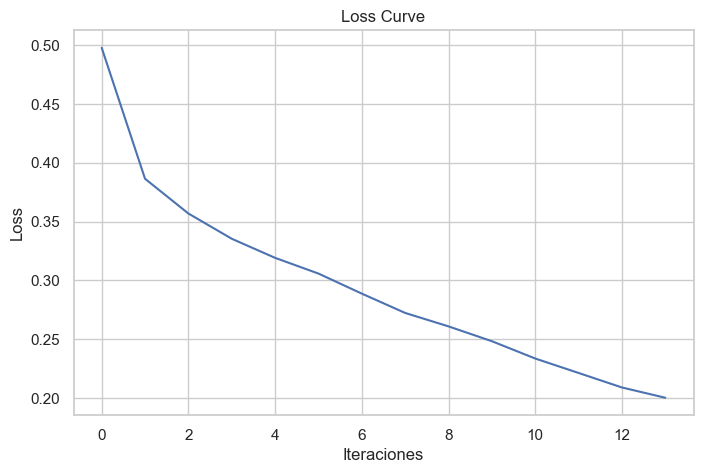

In [128]:
plt.figure(figsize=(8,5))

plt.plot(mlp.loss_curve_)

plt.title("Loss Curve")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")

plt.show()

Como se pude observar, a medida que van aumentando las iteraciones la pérdida ha pasado de ser casi 0.60 a ser <0.30. Así, el modelo cada vez se va entrenando y aprendiendo mejor.

In [129]:
print("Número de capas:", mlp.n_layers_)
print("Número de iteraciones:", mlp.n_iter_)
print("Loss final:", mlp.loss_)

Número de capas: 5
Número de iteraciones: 14
Loss final: 0.20028285186568606


El número de iteraciones utilizadas han sido 24, por lo que para ese valor el modelo está entrenado.
El valor de la pérdida final (0.2678999211647302) indica que existe una diferencia relativamente pequeña entre las predicciones realizadas por la red neuronal y los valores reales del dataset.

#### **Curva ROC**

La curva ROC (*Receiver Operating Characteristic*) representa la capacidad del modelo para distinguir entre clases positivas y negativas utilizando distintos umbrales de decisión.

El valor AUC mide la calidad global del clasificador:

- 0.5 es el clasificador aleatorio
- 1.0 es el clasificador perfecto

En el eje X se representa la tasa de falsos positivos mientras que en el eje Y se representa el recall. La línea diagonal representa un clasificador aleatorio. Cuanto más se acerque la curva a la esquina superior izquierda, mejor será el rendimiento del modelo.

In [130]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, pred_probs)

print("ROC-AUC:", auc)

ROC-AUC: 0.849918349393034


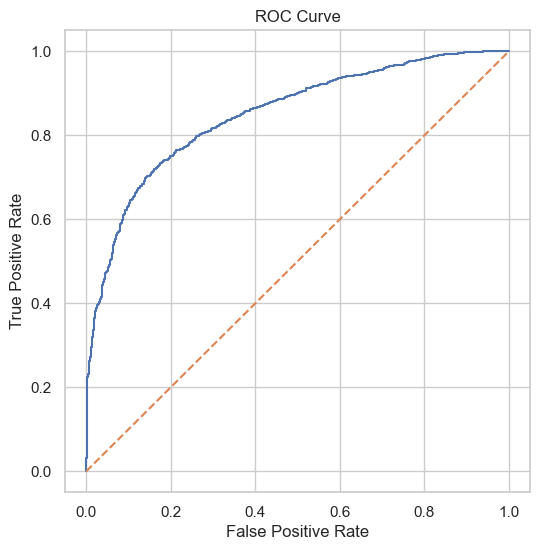

In [131]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, pred_probs)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [53]:
El valor ROC-AUC obtenido fue aproximadamente 0.86, lo que indica buena capacidad del modelo para clasificar la supervivencia de los pacientes. La curva ROC se sitúa claramente por encima de la diagonal correspondiente a un clasificador aleatorio, mostrando que la red neuronal distingue entre ambas clases (0 y 1).

Así, esta métrica nos permite evaluar la capacidad del sistema para detectar correctamente pacientes enfermos minimizando los errores de clasificación.

In [132]:
from sklearn.inspection import permutation_importance

# Calcular importancia
resultado = permutation_importance(
    mlp,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

# Crear DataFrame
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': resultado.importances_mean
})

# Ordenar
importancias = importancias.sort_values(
    by='Importancia',
    ascending=False
)

# Mostrar Top 15
top15 = importancias.head(15)

top15

,Variable,Importancia
40,dzclass_Cancer,0.035359
37,dzgroup_Lung Cancer,0.029466
52,dnr_no dnr,0.026501
7,avtisst,0.026391
56,sfdm2_no(M2 and SIP pres),0.024671
0,age,0.017936
45,race_black,0.013909
48,race_white,0.013690
57,referencia_clinica_CHF Prognostic Factors,0.010322
38,dzgroup_MOSF w/Malig,0.008126


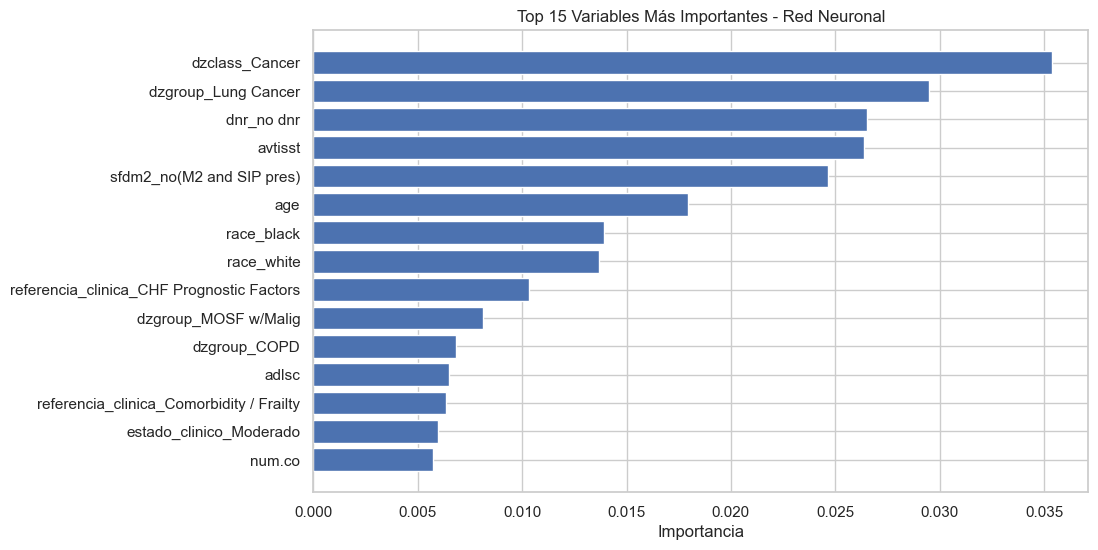

In [133]:
plt.figure(figsize=(10,6))

plt.barh(
    top15['Variable'][::-1],
    top15['Importancia'][::-1]
)

plt.xlabel("Importancia")
plt.title("Top 15 Variables Más Importantes - Red Neuronal")

plt.show()

#### **Conclusiones de la red neuronal ligera**

La red neuronal implementada mediante un modelo MLP (*Multilayer Perceptron*) ha mostrado un rendimiento sólido en la predicción de supervivencia de pacientes.

El modelo alcanza una precisión de un 83% y un valor ROC-AUC aproximado de 0.86, lo que indica una buena detección del riesgo entre los pacientes de los 5 centros médicos de EEUU. Además, dado que nuestro objetivo del trabajo necesita que los falsos negativos se reduzcan lo máximo posible, el recall es bastante bueno, teniendo un valor de un 86%. Así, la mayoría de los pacientes son detectados correctamente, sin haber casi pacientes a los cuales no se les ha detectado su riesgo de muerte pero que deberían de habérselo detectado. Esta idea es fundamental en el ámbito sanitario, para así prevenir la falta de atención médica de pacientes con un riesgo considerable.


#### **Interpretabilidad del modelo**
La interpretabilidad del modelo disminuye conforme aumenta el número de variables utilizadas, ya que resulta más difícil comprender qué factores están influyendo realmente en las predicciones. Al tratarse de una red neuronal ligera, compuesta únicamente por tres capas ocultas (64, 32 y 16 neuronas), la complejidad del modelo sigue siendo moderada en comparación con arquitecturas profundas de Deep Learning.

El análisis de importancia de variables mediante Permutation Importance muestra que la red neuronal está utilizando variables clínicamente coherentes para realizar las predicciones.

La variable más influyente es `sfdm2`, relacionada con el estado funcional del paciente, lo cual tiene una fuerte coherencia médica, ya que el deterioro funcional suele asociarse a mayor mortalidad y peor capacidad de recuperación.

Asimismo, destaca la variable `dnr` (Do Not Resuscitate), que representa órdenes de no reanimación. Este resultado es esperable desde el punto de vista clínico, dado que este tipo de decisiones suelen estar asociadas a pacientes con pronóstico grave o enfermedades avanzadas.

La edad (`age`) también aparece entre las variables más importantes, reflejando el impacto de la fragilidad y las comorbilidades sobre la supervivencia.

Además, varias variables relacionadas con enfermedades oncológicas (`Lung Cancer`, `Colon Cancer`, `Cancer`) presentan elevada relevancia, indicando que la red neuronal aprende correctamente la asociación entre patologías graves y riesgo de fallecimiento.

Variables fisiológicas y respiratorias como `pafi` o `COPD` también contribuyen significativamente al modelo.

De esta manera, la red neuronal no está aprendiendo patrones aleatorios, sino relaciones clínicas consistentes y relevantes para la predicción de supervivencia y fallecimientos.

#### **Interés** 

El uso de redes neuronales en predicción clínica resulta especialmente interesante debido a su capacidad para modelar relaciones no lineales complejas entre variables médicas. El MLP puede aprender interacciones complejas entre las distintas variables del dataset, permitiendo capturar patrones de riesgo difíciles de detectar mediante técnicas más simples. Además, la utilización de funciones de activación ReLU y optimización mediante Adam permite mejorar la convergencia y estabilidad del entrenamiento.

#### **Novedad del modelo**

La aplicación de redes neuronales sobre datasets clínicos estructurados sigue teniendo gran interés en el ámbito biomédico. Se busca construir modelos eficientes sin necesidad de recurrir a arquitecturas profundas complejas ni grandes recursos computacionales. Además, el empleo de técnicas modernas de evaluación como ROC-AUC, curvas ROC y Permutation Importance aporta robustez metodológica al análisis.

#### **Precisión** 

En términos de precisión (83%), la red neuronal presenta una precisión alta. Aun así, el modelo no alcanza una precisión perfecta, lo cual es esperable en problemas médicos reales donde existe una alta complejidad biológica y variabilidad clínica entre pacientes.


#### **Coste estimado de la aplicación de la red neuronal ligera**

Una de las ventajas principales del modelo implementado es su bajo coste computacional.

Al tratarse de una red neuronal ligera:

- No requiere GPU
- Puede entrenarse en CPU convencional
- Presenta tiempos de entrenamiento reducidos
- Consume pocos recursos de memoria

La complejidad computacional es considerablemente menor a una red neuronal compleja con TensorFlow y Keras.

# 6.5.2 Red neuronal compleja (TensorFlow y Keras)

# Deep Learning con TensorFlow y Keras

TensorFlow y Keras permiten implementar redes neuronales profundas reales (Deep Neural Networks).

# Arquitectura profunda

La arquitectura implementada incluye:

- múltiples capas densas
- regularización Dropout
- activación ReLU
- salida Sigmoide

In [134]:
tf.keras.utils.set_random_seed(42)

model = Sequential([

    Input(shape=(X_train_bal_scaled.shape[1],)),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [135]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

Early Stopping permite detener automáticamente el entrenamiento cuando la pérdida de validación deja de mejorar. Esto evita el sobreajuste (overfitting).

In [136]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

# Entrenamiento de la red neuronal

Durante cada epoch la red neuronal:

1. Realiza forward propagation
2. Calcula el error
3. Aplica backpropagation
4. Actualiza pesos mediante gradient descent

El objetivo es minimizar la función de pérdida.

In [137]:
history = model.fit(

    X_train_bal_scaled,
    y_train_bal,

    validation_split=0.2,

    epochs=200,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/200
217/217 [==============================] - 4s 11ms/step - loss: 0.5258 - accuracy: 0.7301 - val_loss: 0.4658 - val_accuracy: 0.8376
Epoch 2/200
217/217 [==============================] - 2s 9ms/step - loss: 0.4548 - accuracy: 0.7765 - val_loss: 0.3810 - val_accuracy: 0.8721
Epoch 3/200
217/217 [==============================] - 2s 8ms/step - loss: 0.4371 - accuracy: 0.7824 - val_loss: 0.3695 - val_accuracy: 0.8704
Epoch 4/200
217/217 [==============================] - 2s 7ms/step - loss: 0.4255 - accuracy: 0.7913 - val_loss: 0.2574 - val_accuracy: 0.9078
Epoch 5/200
217/217 [==============================] - 2s 8ms/step - loss: 0.4163 - accuracy: 0.7958 - val_loss: 0.2518 - val_accuracy: 0.9176
Epoch 6/200
217/217 [==============================] - 2s 8ms/step - loss: 0.4082 - accuracy: 0.7984 - val_loss: 0.2732 - val_accuracy: 0.9009
Epoch 7/200
217/217 [==============================] - 2s 8ms/step - loss: 0.4014 - accuracy: 0.8050 - val_loss: 0.2410 - val_accuracy: 0.921

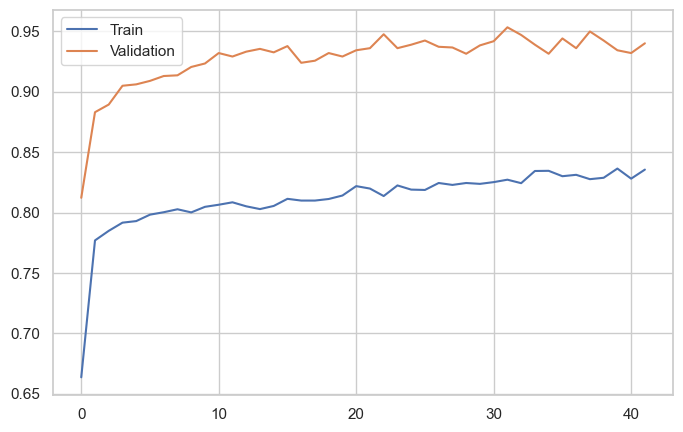

In [105]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.show()

In [102]:
pred_probs = model.predict(
    X_test_scaled
)

predicciones = (
    pred_probs > 0.5
).astype(int)

86/86 [==============================] - 0s 2ms/step


In [103]:
print(classification_report(
    y_test,
    predicciones
))

              precision    recall  f1-score   support

           0       0.50      0.00      0.00       871
           1       0.68      1.00      0.81      1861

    accuracy                           0.68      2732
   macro avg       0.59      0.50      0.41      2732
weighted avg       0.62      0.68      0.55      2732



# Conclusiones

La red neuronal multicapa ha permitido modelar relaciones complejas entre las variables clínicas y la variable objetivo.

La utilización de funciones de activación no lineales como ReLU permite aprender patrones complejos presentes en los datos médicos.

Asimismo, la función sigmoide de salida permite interpretar la predicción como una probabilidad de fallecimiento.

La inclusión de Dropout y Early Stopping ayuda a reducir el overfitting y mejorar la capacidad de generalización del modelo.

# Comparación entre MLP y Deep Learning

MLPClassifier constituye una red neuronal ligera adecuada para:

- datasets pequeños
- aprendizaje académico
- prototipos rápidos

Sin embargo, TensorFlow/Keras ofrece:

- arquitecturas profundas
- mejor regularización
- mayor capacidad de aprendizaje
- entrenamiento optimizado

Por ello, las redes profundas suelen ofrecer mejores resultados en problemas complejos y datasets clínicos reales.

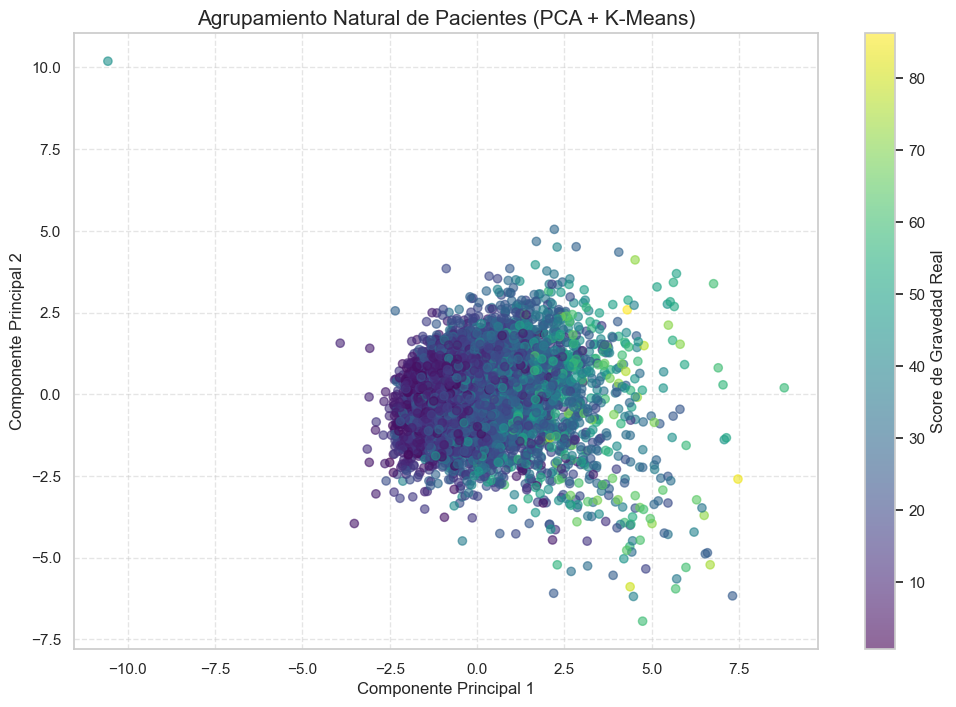

In [176]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.show()

# 8. Evaluación Comparativa de Modelos

Aquí pueden añadirse modelos adicionales (Decision Tree, Neural Network, etc.) y compararse según:
- Accuracy
- Interpretability
- Coste computacional
- Utilidad práctica

| Modelo | Accuracy | Recall (clase 1) | Precisión (clase 1)|
|---|---|---|---|
| Decision Tree | Pendiente | Pendiente | Pendiente |
| Regresión logística | Pendiente | Pendiente | Pendiente |
| K-Nearest Neighbors (KNN) | Pendiente | Pendiente | Pendiente |
| Random Forest | 0,78 | 0,89 | 0,81 |
| Red Neuronal | 0,78 | 0,84 | 0,84 |
